# The Well Forge Report

Author: Michael Hansen

Date: 6/9/2026

Version: 3 (pruned-tabular copy)

**Copy-only:** After merge + roll/lag, **`wellbore_feature_pruning`** can drop highly correlated numeric columns and export merged CSVs to **`data/tabular_pruned/`** (see the block before the LightGBM cell). Raw **`data/train`**, **`data/test`**, **`data/train_tidy`**, and **`data/tidytest`** are not modified.

**Version 3 notes (this notebook):**
- **Joined features:** stacks read **`data/train_tidy/`** lateral + paired typewell CSVs; merge is implemented in **`wellbore_join.attach_typewell_by_tvt`** (imported in the notebook). Tabular contract includes **`tw_GR_interp`** (NaN outside the deduped typewell TVT span), **`tw_interp_missing`**, **`tw_gr_extrapolation_zone`**, replicated **`lat_tvt_below_tw_min`** / **`lat_tvt_above_tw_max`**, optional **`tw_Geology`**, and fold-encoded **`tw_geology_code`**.
- **Geology encoding policy:** each CV fold rebuilds **`build_geology_code_map`** (from **`wellbore_geology`**) from **training-fold** `tw_Geology` only, then **`encode_merged_tw_geology`** on **train and validation** for that fold (code **0** for unseen labels; no val-vocabulary leakage).
- **Masking / metrics:** raw **`TVT_input`** keeps sponsor NaNs (evaluation-style zone); **`TVT_input_ffill`** is an auxiliary MD-smoothed channel. Offline RMSE uses **`VAL_METRIC_ROWS`**: **`all_labeled`** (default) vs **`eval_zone`** ( **`TVT_input`** NaN and manual **`TVT`** present). Target remains **manual `TVT`**; **RMSE(pred, manual)** equals **RMSE on `dTVT`**. **`tw_GR_interp`** is not zero-filled.
- **V3 roadmap:** Phased milestones and approval gates live in **`V3_plan.md`** (rolling / lag / boundary features; **`sample_submission.csv`**-aligned inference).
- **Milestone 1 (shipped):** **`wellbore_features.add_alonghole_roll_features`** — per-well rolling **mean / median / d(signal)/dMD** for **MD**, **Z**, **`tw_GR_interp`**, **GR** over **5 / 10 / 20 ft** (row windows after MD sort); toggled in the LightGBM cell via **`USE_V3_ROLL_FEATURES`**.
- **Milestone 2 (shipped):** **`wellbore_features.add_alonghole_lag_features`** — per-well **lag**, **diff**, and **ratio** (current over lagged value) for **MD**, **Z**, **`tw_GR_interp`**, **GR** at **3 / 5 / 10 ft** back along hole (~1 ft/row; first *k* feet per well are **NaN**). Toggle via **`USE_V3_LAG_FEATURES`**.

In [1]:
# imports & Libraries
from __future__ import annotations
from collections.abc import Iterable
from pathlib import Path
from IPython.display import Image, display


import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import random
import pandas as pd
import shutil

import wellbore_cv as wcv
import wellbore_features as wbfeat

# Depth Charge — Wellbore Geology Prediction

## Introduction and competition context

This notebook is the working **report and progress log** for the [ROGII - Wellbore Geology Prediction](https://www.kaggle.com/competitions/rogii-wellbore-geology-prediction) entry on Kaggle.

**Tabular baseline (V2 pipeline; carried into this V3 notebook)**

The working baseline mirrors intended **tabular** competition features before images or heavy sequence models:

- **Joined lateral + typewell:** each foot is built from **`train_tidy`**, merged on **TVT**, and carries **`tw_GR_interp`**, join-health flags (**`tw_interp_missing`**, **`tw_gr_extrapolation_zone`**, **`lat_tvt_below_tw_min`**, **`lat_tvt_above_tw_max`**), optional **`tw_Geology`**, and encoded **`tw_geology_code`**.
- **Geology encoding:** helpers live in **`wellbore_geology`** — **`build_geology_code_map`** is refit **per CV fold** on **train-fold** `tw_Geology` labels only; **`encode_merged_tw_geology`** is then applied to **train and validation** stacks for that fold (fold-safe; val-only strings map to code **0**).
- **Masking & targets:** **`TVT_input`** retains competition NaNs in the masked channel; **`TVT_input_ffill`** is an optional smoothed companion. The model predicts **manual `TVT`**; reported **RMSE(pred, manual)** matches leaderboard-style **RMSE on `dTVT`**. **`VAL_METRIC_ROWS`** (see model cell) selects **`all_labeled`** vs **`eval_zone`** validation feet for the printed RMSE.

`ReadMe.md`  
`Methodology.md`

---


In [2]:
REPO_ROOT = Path.cwd()

DATA_TRAIN = REPO_ROOT / "data" / "train"
DATA_TEST = REPO_ROOT / "data" / "test"

## <center> Data analysis </center>

Reference `explore_data.py` 

To begin the exploratory data analysis, I went ahead and pulled a few common algorithms for Stepping over and parsing CSV files As well as Strolling through files and performing some simple analysis on The data I downloaded versus the data card on Kaggle. The data card claimed that there would be matching CSV files and an accompanying PNG file per every Well in the training set. According to the script, it does match.

The next tasl was to perform some simple mathematical analysis on the numerical columns and to count NAs. In the interest of just exploring I started with just a sampling of the first 5000 rows for each data set. 

### <center> File Distribution analysis </center>

--- PNGs vs lateral CSV stems ---

Unique lateral stems from horizontal CSVs: 773

Unique keys from PNG basenames (stem, or text before '__'): 773

Stems appearing in both: 773

PNG shape/size sample (first 3 files):

  * 000d7d20.png: 4984x2805 px, 828,522 bytes
  * 00bbac68.png: 5010x2805 px, 830,428 bytes
  * 00e12e8b.png: 4984x2805 px, 797,443 bytes

--- Lateral / typewell pairing (from filenames) ---

Paired stems (appear in both): 773

Lateral stem without typewell file: 0

Typewell stem without lateral file: 0

--- Typewell CSVs ---

Count: 776  (unique lateral stems from filenames: 773)

--- Horizontal well CSVs ---

Count: 776  (unique name stems: 773)

---





### <center> Sample of the data </center>

I decided to pull random samples so that I could speedily refresh through the cell and take a glimpse Through the data. There is a distinct amount of NAS in the geology column.Throughout, SO I definitely wanted to get a clear picture of this. We go back and expand on the exploratory_data.py To add a fractional Viewpoint, in a numerical sense. There is quite a large amount In some of these CSVS, We will need to figure out how to handle these NAs. 

Before I go too much farther in developing a plan though, I want to get a quick visual representation of the distribution of the ratios of NAS Present.

Sample file: data\train\da940160.png


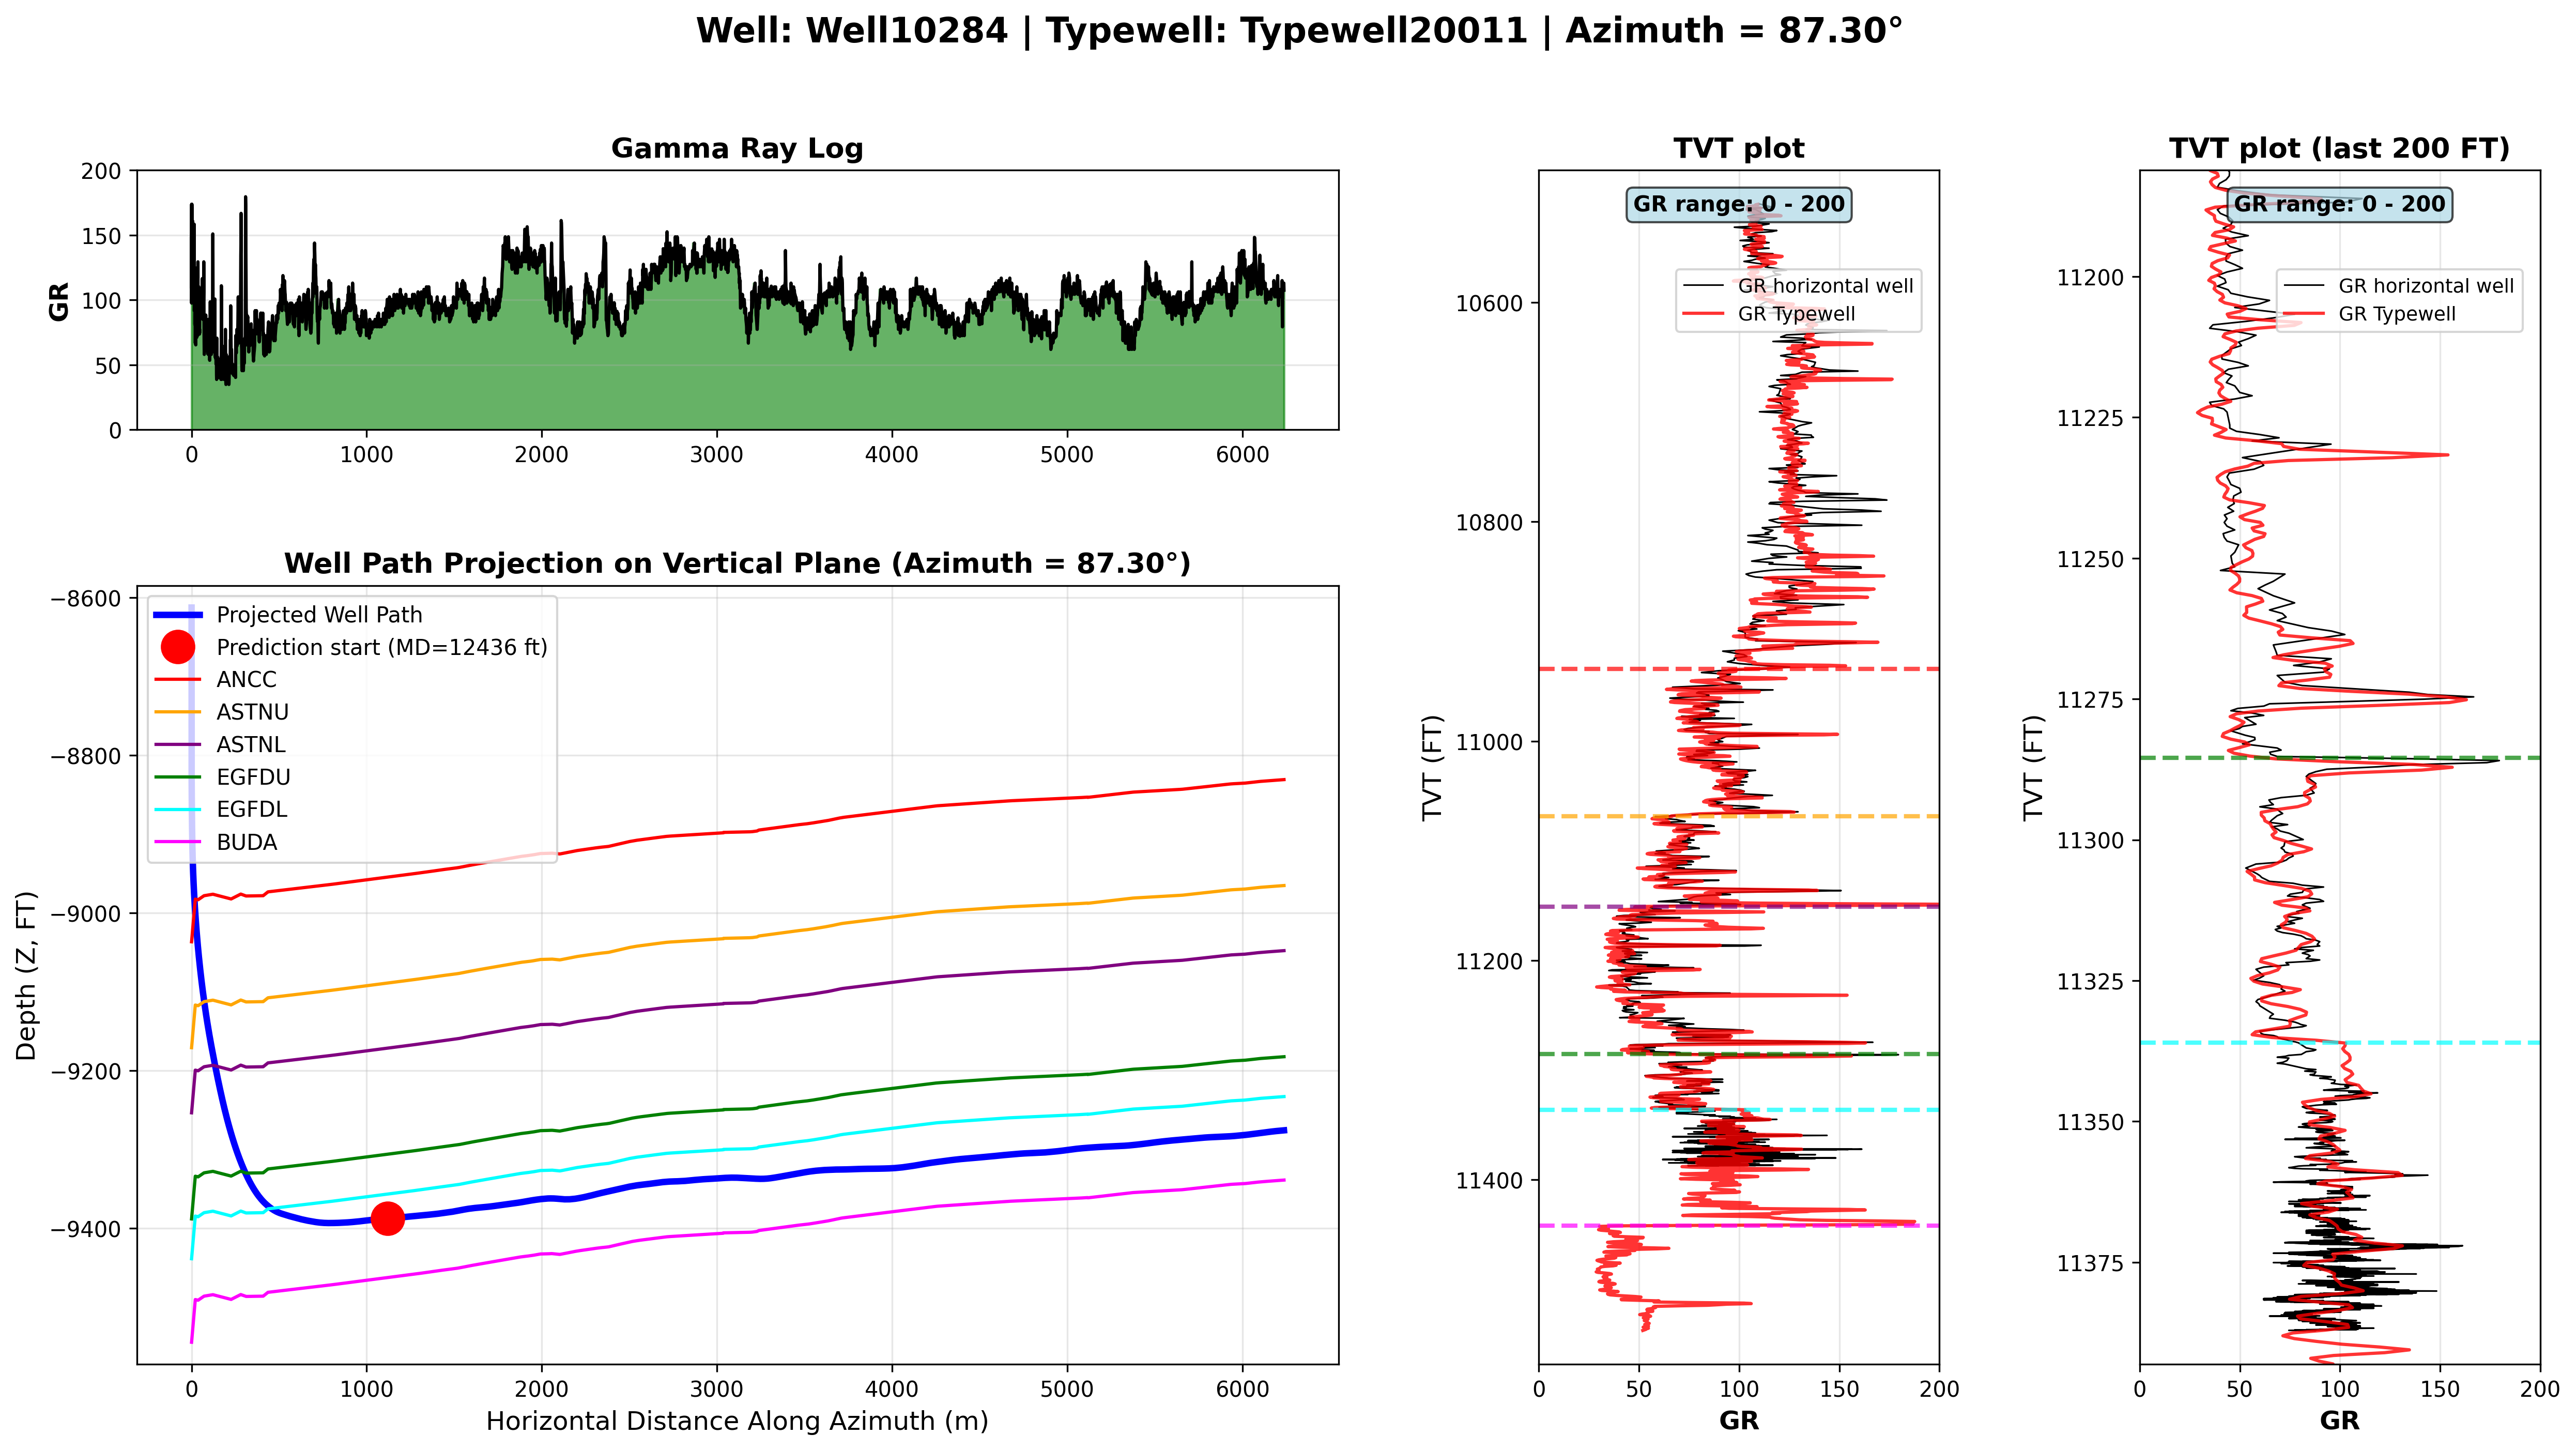

Sample file: data\train\da940160__horizontal_well.csv
        MD           X           Y        Z     ANCC    ASTNU    ASTNL  \
0  10777.0  3006996.20  1116392.68 -8612.52 -9036.40 -9170.76 -9253.31   
1  10778.0  3006996.20  1116392.69 -8613.52 -9036.39 -9170.74 -9253.30   
2  10779.0  3006996.20  1116392.69 -8614.52 -9036.38 -9170.73 -9253.29   
3  10780.0  3006996.19  1116392.70 -8615.52 -9036.37 -9170.72 -9253.28   
4  10781.0  3006996.19  1116392.70 -8616.52 -9036.36 -9170.71 -9253.27   

     EGFDU    EGFDL     BUDA       TVT          GR  TVT_input  
0 -9387.84 -9438.38 -9544.26  10510.13  110.104481   10510.13  
1 -9387.83 -9438.37 -9544.25  10511.14         NaN   10511.14  
2 -9387.82 -9438.36 -9544.24  10512.16         NaN   10512.16  
3 -9387.81 -9438.35 -9544.23  10513.17  116.853443   10513.17  
4 -9387.80 -9438.34 -9544.22  10514.18  104.319658   10514.18  
Sample file: data\train\da940160__typewell.csv
        TVT      GR Geology
0  10497.93  110.42     NaN
1  10498.43  1

In [3]:
# One random image sample
png_paths = sorted({p.resolve(): p for p in DATA_TRAIN.rglob("*.png")}.values())
sample_png = random.Random(42).choice(png_paths)
print(f"Sample file: {sample_png.relative_to(REPO_ROOT)}")
# Constrain width for easier viewing.
display(Image(filename=str(sample_png), width=900))

# One random horizontal CSV sample
horizontal_paths = sorted(
    {
        p.resolve(): p
        for p in DATA_TRAIN.rglob("*__horizontal_well.csv")
    }.values()
)
sample_horizontal = random.Random(42).choice(horizontal_paths)
print(f"Sample file: {sample_horizontal.relative_to(REPO_ROOT)}")
sample_horizontal_df = pd.read_csv(sample_horizontal)
print(sample_horizontal_df.head())

# One random typewell CSV sample
typewell_paths = sorted(
    {
        p.resolve(): p
        for p in DATA_TRAIN.rglob("*__typewell.csv")
    }.values()
)
sample_typewell = random.Random(42).choice(typewell_paths)
print(f"Sample file: {sample_typewell.relative_to(REPO_ROOT)}")
sample_typewell_df = pd.read_csv(sample_typewell)
print(sample_typewell_df.head())

print(sample_horizontal_df.columns)
print(sample_typewell_df.columns)

### <center> Join mechanics — Iteration 1 </center>

**Goal:** show that lateral **manual `TVT`** (train only) lives in the same vertical frame as typewell **`TVT`**, by pulling typewell **GR** onto each lateral foot.

- **Pinned well:** `JOIN_PROBE_WELL_ID` below (change to another hash if you want a different well).
- **Method:** try an **exact** `merge` on `TVT` (often **sparse hits** because the typewell has fewer TVT rows than the lateral has feet); 
    - Geology strings need a separate rule (nearest TVT / interp phase later).
    - Each block is one idea: load → typewell knots → exact merge → interp → checks → sample table.


In [4]:
# ---------------------------------------------------------------------------
# Iteration 1 — lateral TVT vs typewell TVT (fixed well, train diagnostic)
# ---------------------------------------------------------------------------
# Educational focus: same-well pairing is checked by (1) sparse *exact* TVT
# matches and (2) dense *interpolated* typewell GR on every lateral TVT.

join_data_root = wcv.default_train_root()

# Pinned well for reproducible figures; if CSVs are missing, fall back to the
# first lateral discovered under join_data_root.
JOIN_PROBE_WELL_ID = "da940160"
lateral_csv_path = join_data_root / f"{JOIN_PROBE_WELL_ID}__horizontal_well.csv"
typewell_csv_path = join_data_root / f"{JOIN_PROBE_WELL_ID}__typewell.csv"

if not (lateral_csv_path.is_file() and typewell_csv_path.is_file()):
    lateral_paths_sorted = sorted(
        {p.resolve(): p for p in join_data_root.rglob("*__horizontal_well.csv")}.values(),
        key=lambda path: path.name,
    )
    if not lateral_paths_sorted:
        raise FileNotFoundError(f"No laterals under: {join_data_root}")
    JOIN_PROBE_WELL_ID = wcv.lateral_well_stem(lateral_paths_sorted[0]) or lateral_paths_sorted[
        0
    ].stem.split("__")[0]
    lateral_csv_path = join_data_root / f"{JOIN_PROBE_WELL_ID}__horizontal_well.csv"
    typewell_csv_path = join_data_root / f"{JOIN_PROBE_WELL_ID}__typewell.csv"

print("join_data_root:", join_data_root.relative_to(REPO_ROOT))
print("JOIN_PROBE_WELL_ID:", JOIN_PROBE_WELL_ID)

lateral_df = pd.read_csv(lateral_csv_path)
typewell_df = pd.read_csv(typewell_csv_path)

print("lateral row count (one row per lateral foot in this file):", len(lateral_df))
print("typewell row count (vertical samples):", len(typewell_df))

assert "TVT" in lateral_df.columns, lateral_df.columns.tolist()
assert "TVT" in typewell_df.columns and "GR" in typewell_df.columns, typewell_df.columns.tolist()

# --- Build a clean typewell TVT axis for merge + interpolation ----------------
# Stable sort so "last wins" dedup is deterministic (same as later iterations).
typewell_sorted_by_tvt = typewell_df.sort_values("TVT", kind="mergesort")
typewell_duplicate_tvt_mask = typewell_sorted_by_tvt["TVT"].duplicated(keep=False)
if typewell_duplicate_tvt_mask.any():
    print(
        "typewell rows sharing a duplicate TVT key:",
        int(typewell_duplicate_tvt_mask.sum()),
        "(for interp we keep last row per TVT after sort)",
    )

typewell_one_row_per_tvt = typewell_sorted_by_tvt.drop_duplicates(subset=["TVT"], keep="last")
typewell_tvt_knots = typewell_one_row_per_tvt["TVT"].to_numpy(dtype=float)
typewell_gr_at_knots = typewell_one_row_per_tvt["GR"].to_numpy(dtype=float)



join_data_root: data\train_tidy
JOIN_PROBE_WELL_ID: da940160
lateral row count (one row per lateral foot in this file): 6792
typewell row count (vertical samples): 2081


In [5]:
# --- Exact merge: only rows where lateral TVT equals a typewell TVT exactly ---
if "Geology" in typewell_df.columns:
    typewell_for_exact_merge = typewell_one_row_per_tvt.rename(
        columns={"GR": "tw_GR", "Geology": "tw_Geology"}
    ).copy()
else:
    typewell_for_exact_merge = typewell_one_row_per_tvt.rename(columns={"GR": "tw_GR"}).copy()

exact_merge_columns = ["TVT", "tw_GR"] + (
    ["tw_Geology"] if "tw_Geology" in typewell_for_exact_merge.columns else []
)
merged = lateral_df.merge(typewell_for_exact_merge[exact_merge_columns], on="TVT", how="left")

# --- Interpolate typewell GR onto every lateral TVT (primary join signal) -----
# np.interp evaluates piecewise-linear GR between typewell knots. Outside the
# knot span we force NaN (no silent extrapolation).
lateral_tvt_all = lateral_df["TVT"].to_numpy(dtype=float)
lateral_tvt_finite_mask = np.isfinite(lateral_tvt_all)

tw_gr_interp = np.full_like(lateral_tvt_all, np.nan, dtype=float)
tw_gr_interp[lateral_tvt_finite_mask] = np.interp(
    lateral_tvt_all[lateral_tvt_finite_mask],
    typewell_tvt_knots,
    typewell_gr_at_knots,
    left=np.nan,
    right=np.nan,
)
merged["tw_GR_interp"] = tw_gr_interp

# --- Sanity: where exact merge exists, interpolated GR should match ----------
has_exact_tw_gr = merged["tw_GR"].notna()
has_interp_tw_gr = merged["tw_GR_interp"].notna()
both_exact_and_interp = has_exact_tw_gr & has_interp_tw_gr

if both_exact_and_interp.any():
    max_abs_diff_exact_vs_interp = (
        merged.loc[both_exact_and_interp, "tw_GR"] - merged.loc[both_exact_and_interp, "tw_GR_interp"]
    ).abs().max()
    print("rows with both exact-merge tw_GR and interp:", int(both_exact_and_interp.sum()))
    print("max |exact - interp| on those rows:", float(max_abs_diff_exact_vs_interp))
else:
    print("no overlapping exact-merge GR rows (check TVT dtypes / overlap)")

fraction_exact_tvt_match = merged["tw_GR"].notna().mean()
fraction_finite_interp = np.isfinite(merged["tw_GR_interp"]).mean()
print("fraction lateral rows with exact TVT match on typewell:", float(fraction_exact_tvt_match))
print("fraction finite tw_GR_interp:", float(fraction_finite_interp))



rows with both exact-merge tw_GR and interp: 162
max |exact - interp| on those rows: 0.0
fraction lateral rows with exact TVT match on typewell: 0.023851590106007067
fraction finite tw_GR_interp: 1.0


In [6]:
# --- Context: why exact match rate is usually low --------------------------------
print(
    "\nNote: A low exact-match rate is normal when typewell samples are not on the same",
    "1 ft lateral TVT floats; interp is the dense proof of a shared TVT axis.",
)
delta_tvt_between_typewell_knots = np.diff(typewell_tvt_knots)
print(
    "typewell unique TVT knot count:",
    len(typewell_tvt_knots),
    "| median |delta TVT| between knots (ft):",
    float(np.median(np.abs(delta_tvt_between_typewell_knots))) if len(delta_tvt_between_typewell_knots) else None,
    "| typewell TVT span:",
    float(np.min(typewell_tvt_knots)),
    "..",
    float(np.max(typewell_tvt_knots)),
)

# Distance from each lateral TVT (finite only) to the nearest typewell knot
insert_positions = np.searchsorted(typewell_tvt_knots, lateral_tvt_all[lateral_tvt_finite_mask], side="left")
left_knot_index = np.clip(insert_positions - 1, 0, len(typewell_tvt_knots) - 1)
right_knot_index = np.clip(insert_positions, 0, len(typewell_tvt_knots) - 1)
distance_to_nearest_knot_ft = np.minimum(
    np.abs(lateral_tvt_all[lateral_tvt_finite_mask] - typewell_tvt_knots[left_knot_index]),
    np.abs(lateral_tvt_all[lateral_tvt_finite_mask] - typewell_tvt_knots[right_knot_index]),
)
print(
    "lateral TVT to nearest typewell knot: median distance (ft):",
    float(np.median(distance_to_nearest_knot_ft)),
    "| p95:",
    float(np.quantile(distance_to_nearest_knot_ft, 0.95)),
    "| fraction within 1e-3 ft of a knot (approx exact-match rate):",
    float((distance_to_nearest_knot_ft < 1e-3).mean()) if distance_to_nearest_knot_ft.size else None,
)

# Correlation: horizontal GR vs vertical GR pulled to the same lateral TVTs
finite_interp_mask = merged["GR"].notna() & np.isfinite(merged["tw_GR_interp"])
if finite_interp_mask.sum() > 10:
    corr_lateral_vs_interp_tw_gr = merged.loc[finite_interp_mask, "GR"].corr(
        merged.loc[finite_interp_mask, "tw_GR_interp"]
    )
    print(
        "corr(lateral GR, tw_GR_interp @ lateral TVT — all finite interp rows):",
        float(corr_lateral_vs_interp_tw_gr),
    )

# --- Small random checkpoint table (fixed RNG) -------------------------------
rng = np.random.default_rng(0)
n_sample_rows = min(8, len(merged))
random_row_indices = rng.choice(len(merged), size=n_sample_rows, replace=False)
display_columns = ["MD", "TVT", "GR", "tw_GR", "tw_GR_interp"]
if "tw_Geology" in merged.columns:
    display_columns.append("tw_Geology")
format_subset = [c for c in ["TVT", "MD", "GR", "tw_GR", "tw_GR_interp"] if c in display_columns]
display(
    merged.loc[sorted(random_row_indices), display_columns].style.format(
        {"TVT": "{:.3f}", "MD": "{:.1f}", "GR": "{:.2f}", "tw_GR": "{:.2f}", "tw_GR_interp": "{:.2f}"},
        subset=format_subset,
    )
)

# correlation on the small exact-merge subset only
exact_merge_mask = merged["tw_GR"].notna() & merged["GR"].notna()
if exact_merge_mask.sum() > 10:
    corr_sparse_exact_only = merged.loc[exact_merge_mask, "GR"].corr(merged.loc[exact_merge_mask, "tw_GR"])
    print(
        "corr(lateral GR, tw_GR @ same TVT, exact-merge rows only — sparse):",
        float(corr_sparse_exact_only),
    )



Note: A low exact-match rate is normal when typewell samples are not on the same 1 ft lateral TVT floats; interp is the dense proof of a shared TVT axis.
typewell unique TVT knot count: 2081 | median |delta TVT| between knots (ft): 0.5 | typewell TVT span: 10497.93 .. 11537.41
lateral TVT to nearest typewell knot: median distance (ft): 0.12000000000080036 | p95: 0.23999999999796273 | fraction within 1e-3 ft of a knot (approx exact-match rate): 0.023851590106007067
corr(lateral GR, tw_GR_interp @ lateral TVT — all finite interp rows): 0.8232194438342497


,MD,TVT,GR,tw_GR,tw_GR_interp,tw_Geology
112,10889.0,10622.570,136.88,nan,135.64,nan
278,11055.0,10794.970,126.65,nan,130.98,nan
510,11287.0,11065.360,116.51,nan,104.66,nan
1831,12608.0,11368.450,91.79,nan,98.11,nan
2089,12866.0,11369.060,114.93,nan,99.06,nan
3469,14246.0,11371.830,127.89,nan,124.22,nan
4322,15099.0,11381.670,68.02,nan,77.96,nan
5771,16548.0,11379.610,110.10,nan,107.57,nan


corr(lateral GR, tw_GR @ same TVT, exact-merge rows only — sparse): 0.7016122837194284


### Join mechanics — Iteration 2 (edge cases)

**Out-of-range (lateral TVT vs typewell TVT span):** `tw_GR_interp` uses `np.interp(..., left=np.nan, right=np.nan)` so lateral feet **outside** `[min(typewell TVT), max(typewell TVT)]` get **NaN** (not clipped, not extrapolated). Counts per well are in `lat_tvt_below_tw_min`, `lat_tvt_above_tw_max`, `lat_tvt_overlap_rows`.

**Duplicate typewell TVT:** Same as Iteration 1 — sort by TVT (`mergesort`), then `drop_duplicates(subset=["TVT"], keep="last")`. `tw_dedup_dropped` is how many raw rows were removed by that collapse; `tw_dup_tvt_rowcount` counts typewell rows that participate in a duplicate TVT key (before dedup).

**Monotonicity:** Counts of **strict decreases** (`diff < 0`) along **CSV row order** for MD and TVT on lateral and typewell. For the typewell, `tw_tvt_sorted_*` is computed on the **TVT-sorted** series (the grid used for interpolation): `decreases` should be **0** if TVT is orderable; `plateaus` counts `diff == 0` (duplicate TVT keys).

**Checkpoint:** small probe table (`ITER2_PROBE_N` wells), then a larger batch (`ITER2_BATCH_N`). The final table (`iter2_flagged_wells_df`) lists wells where **any** structural flag is positive (including `lat_tvt_roworder_decreases`, which is **common** on horizontals and does not by itself break `np.interp` — read the code comments in that section).

In [7]:
# ---------------------------------------------------------------------------
# Iteration 2 — duplicate TVT, monotonicity, out-of-range (per-well counts)
# ---------------------------------------------------------------------------
# Core diagnostics live in ``wellbore_join_diagnostics``; this cell sets paths for the probe cell.

import wellbore_cv as wcv
from wellbore_join_diagnostics import (
    diagnostics_dataframe_for_well_ids,
    discover_sorted_well_ids,
)

join_data_root = wcv.default_train_root()
well_ids_sorted = discover_sorted_well_ids(join_data_root)

try:
    pinned_well_id = JOIN_PROBE_WELL_ID
except NameError:
    pinned_well_id = well_ids_sorted[0] if well_ids_sorted else None

ITER2_PROBE_N = 8
ITER2_BATCH_N = 40


In [8]:

# --- Probe table: pinned well first (when present), then alphabetically next wells
probe_well_ids: list[str] = []
if pinned_well_id and pinned_well_id in well_ids_sorted:
    probe_well_ids.append(pinned_well_id)
for well_id in well_ids_sorted:
    if well_id not in probe_well_ids:
        probe_well_ids.append(well_id)
    if len(probe_well_ids) >= ITER2_PROBE_N:
        break

print("join_data_root (iter2):", join_data_root.relative_to(REPO_ROOT))
print("lateral wells discovered:", len(well_ids_sorted))
print("ITER2 probe well_ids:", probe_well_ids)

iter2_probe_df = diagnostics_dataframe_for_well_ids(probe_well_ids, join_data_root)
if len(iter2_probe_df):
    display(iter2_probe_df.set_index("well_id"))
else:
    print("No lateral/typewell pairs found under join_data_root — check data paths.")

# --- Larger batch (same columns) ------------------------------------------------
batch_well_ids = well_ids_sorted[: min(ITER2_BATCH_N, len(well_ids_sorted))]
iter2_batch_df = diagnostics_dataframe_for_well_ids(batch_well_ids, join_data_root)
print("\nITER2 batch size:", len(iter2_batch_df), "wells (cap", ITER2_BATCH_N, ")")
with pd.option_context('display.max_rows', 10):
    display(iter2_batch_df.set_index("well_id"))

# --- "Bad" wells for manual review (conservative structural checks) ------------
iter2_structural_flag_columns = [
    "lat_md_decreases",
    "lat_tvt_roworder_decreases",
    "tw_md_decreases",
    "tw_tvt_roworder_decreases",
    "tw_tvt_sorted_decreases",
    "tw_dedup_dropped",
]
if len(iter2_batch_df):
    any_flag_positive = (iter2_batch_df[iter2_structural_flag_columns].fillna(0) > 0).any(axis=1)
    iter2_flagged_wells_df = iter2_batch_df.loc[any_flag_positive].sort_values("well_id")
    print(
        "\nwells with MD/TVT row-order dips, nonzero sorted-TVT decreases, or typewell TVT dedup drops:",
        len(iter2_flagged_wells_df),
        "of",
        len(iter2_batch_df),
    )
    with pd.option_context('display.max_rows', 10):
        display(iter2_flagged_wells_df.set_index("well_id"))


join_data_root (iter2): data\train_tidy
lateral wells discovered: 773
ITER2 probe well_ids: ['da940160', '000d7d20', '00bbac68', '00e12e8b', '015fe0d2', '01869cd4', '01982c1d', '028d7b28']


,lat_rows,lat_md_decreases,tw_md_decreases,lat_tvt_roworder_decreases,tw_tvt_roworder_decreases,tw_dup_tvt_rowcount,tw_rows_raw,tw_unique_tvt,tw_dedup_dropped,tw_tvt_min,tw_tvt_max,lat_tvt_below_tw_min,lat_tvt_above_tw_max,lat_tvt_overlap_rows,tw_interp_finite_frac,tw_tvt_sorted_decreases,tw_tvt_sorted_plateaus
well_id,,,,,,,,,,,,,,,,,
da940160,6792,0,NaN,1809,0,0,2081,2081,0,10497.93,11537.41,0,0,6792,1.0,0,0
000d7d20,5278,0,NaN,1901,0,0,1296,1296,0,11223.95,11871.45,0,0,5278,1.0,0,0
00bbac68,7559,0,NaN,2148,0,0,1946,1946,0,11394.45,12366.95,0,0,7559,1.0,0,0
00e12e8b,6384,0,NaN,1860,0,0,2556,2556,0,10593.95,11871.45,0,0,6384,1.0,0,0
015fe0d2,5950,0,NaN,1735,0,0,1265,1265,0,11734.95,12366.95,0,0,5950,1.0,0,0
01869cd4,6850,0,NaN,2235,0,0,1052,1052,0,11345.95,11871.45,0,0,6850,1.0,0,0
01982c1d,5587,0,NaN,2035,0,0,2213,2213,0,9915.37,11021.27,0,0,5587,1.0,0,0
028d7b28,7761,0,NaN,2262,0,0,1774,1774,0,11862.45,12748.95,0,0,7761,1.0,0,0



ITER2 batch size: 40 wells (cap 40 )


,lat_rows,lat_md_decreases,tw_md_decreases,lat_tvt_roworder_decreases,tw_tvt_roworder_decreases,tw_dup_tvt_rowcount,tw_rows_raw,tw_unique_tvt,tw_dedup_dropped,tw_tvt_min,tw_tvt_max,lat_tvt_below_tw_min,lat_tvt_above_tw_max,lat_tvt_overlap_rows,tw_interp_finite_frac,tw_tvt_sorted_decreases,tw_tvt_sorted_plateaus
well_id,,,,,,,,,,,,,,,,,
000d7d20,5278,0,NaN,1901,0,0,1296,1296,0,11223.95,11871.45,0,0,5278,1.000000,0,0
00bbac68,7559,0,NaN,2148,0,0,1946,1946,0,11394.45,12366.95,0,0,7559,1.000000,0,0
00e12e8b,6384,0,NaN,1860,0,0,2556,2556,0,10593.95,11871.45,0,0,6384,1.000000,0,0
015fe0d2,5950,0,NaN,1735,0,0,1265,1265,0,11734.95,12366.95,0,0,5950,1.000000,0,0
01869cd4,6850,0,NaN,2235,0,0,1052,1052,0,11345.95,11871.45,0,0,6850,1.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109d9d70,5851,0,NaN,1424,0,0,2992,2992,0,11578.33,12325.65,0,0,5851,1.000000,0,0
10a1281a,7353,0,NaN,2506,0,0,1896,1896,0,10418.95,11366.45,0,0,7353,1.000000,0,0
10b89021,7166,0,NaN,2475,0,0,1006,1006,0,11782.62,12285.10,481,0,6685,0.932877,0,0



wells with MD/TVT row-order dips, nonzero sorted-TVT decreases, or typewell TVT dedup drops: 40 of 40


,lat_rows,lat_md_decreases,tw_md_decreases,lat_tvt_roworder_decreases,tw_tvt_roworder_decreases,tw_dup_tvt_rowcount,tw_rows_raw,tw_unique_tvt,tw_dedup_dropped,tw_tvt_min,tw_tvt_max,lat_tvt_below_tw_min,lat_tvt_above_tw_max,lat_tvt_overlap_rows,tw_interp_finite_frac,tw_tvt_sorted_decreases,tw_tvt_sorted_plateaus
well_id,,,,,,,,,,,,,,,,,
000d7d20,5278,0,NaN,1901,0,0,1296,1296,0,11223.95,11871.45,0,0,5278,1.000000,0,0
00bbac68,7559,0,NaN,2148,0,0,1946,1946,0,11394.45,12366.95,0,0,7559,1.000000,0,0
00e12e8b,6384,0,NaN,1860,0,0,2556,2556,0,10593.95,11871.45,0,0,6384,1.000000,0,0
015fe0d2,5950,0,NaN,1735,0,0,1265,1265,0,11734.95,12366.95,0,0,5950,1.000000,0,0
01869cd4,6850,0,NaN,2235,0,0,1052,1052,0,11345.95,11871.45,0,0,6850,1.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109d9d70,5851,0,NaN,1424,0,0,2992,2992,0,11578.33,12325.65,0,0,5851,1.000000,0,0
10a1281a,7353,0,NaN,2506,0,0,1896,1896,0,10418.95,11366.45,0,0,7353,1.000000,0,0
10b89021,7166,0,NaN,2475,0,0,1006,1006,0,11782.62,12285.10,481,0,6685,0.932877,0,0


### Join mechanics — Iteration 3 (output schema, one well)

**Lateral columns:** kept **as in the CSV** (same names and order).

**Typewell-derived columns (fixed names):** `tw_GR` (exact TVT key match), `tw_GR_interp` (`np.interp` onto lateral TVT, out-of-range NaN), `tw_Geology` when the typewell file has `Geology`, `tw_TVT` (typewell TVT on exact matches only; otherwise NaN — useful to spot sparse exact hits vs. lateral `TVT`), **`lat_tvt_below_tw_min`** / **`lat_tvt_above_tw_max`** (per-well counts of finite lateral feet outside the deduped typewell TVT span, replicated on every row), and **`tw_gr_extrapolation_zone`** (1 on a foot where finite lateral TVT lies outside that span; aligns with NaN `tw_GR_interp` from out-of-range). **`tw_interp_missing`** is 1 wherever `tw_GR_interp` is NaN (per-foot binary for the model).

**Collisions:** if any lateral column already uses one of those names, the cell **raises** with a clear error (per your “prefix only if collisions” rule — manual rename is safer than silent churn).

**Checkpoint:** `iter3_merged_df` with shape `(n_lateral_feet, n_cols)`. Toggle **`ITER3_SAVE_CSV`** in the code cell (`False` by default) to write under `data/joined_train/`; **never** writes into `data/train` or `data/train_tidy`.

In [9]:
# ---------------------------------------------------------------------------
# Iteration 3 — stable merged schema (one lateral + paired typewell on TVT)
# ---------------------------------------------------------------------------
# Implementation lives in ``wellbore_join``; this cell imports the API for later cells.

from wellbore_join import TYPEWELL_FEATURE_COLS, merge_lateral_typewell_schema_tvt

ITER3_JOINED_DIR = REPO_ROOT / "data" / "joined_train"
ITER3_SAVE_CSV = False  # True writes one CSV under data/joined_train/ (gitignored); never touches train_tidy
ITER3_TYPEWELL_FEATURE_COLS = TYPEWELL_FEATURE_COLS  # backward-compatible alias


In [10]:

# --- Example: build merged frame for one well (reload CSVs for a clean copy) --
iter3_join_data_root = wcv.default_train_root()
try:
    example_well_id = JOIN_PROBE_WELL_ID
except NameError:
    lateral_paths = wcv.discover_lateral_csvs(iter3_join_data_root)
    if not lateral_paths:
        raise FileNotFoundError(f"No laterals under {iter3_join_data_root}")
    example_well_id = wcv.lateral_well_stem(lateral_paths[0]) or lateral_paths[0].stem.split("__")[0]

example_lateral_path = iter3_join_data_root / f"{example_well_id}__horizontal_well.csv"
example_typewell_path = iter3_join_data_root / f"{example_well_id}__typewell.csv"
if not (example_lateral_path.is_file() and example_typewell_path.is_file()):
    raise FileNotFoundError(f"Missing pair for well_id={example_well_id!r}: {example_lateral_path} / {example_typewell_path}")

example_lateral_df = pd.read_csv(example_lateral_path)
example_typewell_df = pd.read_csv(example_typewell_path)

iter3_merged_df = merge_lateral_typewell_schema_tvt(example_lateral_df, example_typewell_df)

print("well_id:", example_well_id)
print("join_data_root:", iter3_join_data_root.relative_to(REPO_ROOT))
print("iter3_merged_df shape (n_lateral_feet, n_cols):", iter3_merged_df.shape)
print("n lateral source columns:", len(example_lateral_df.columns))
print(
    "typewell feature columns present:",
    [c for c in ITER3_TYPEWELL_FEATURE_COLS if c in iter3_merged_df.columns],
)
print("column order (first 12):", list(iter3_merged_df.columns[:12]), "...")

if ITER3_SAVE_CSV:
    ITER3_JOINED_DIR.mkdir(parents=True, exist_ok=True)
    out_csv_path = ITER3_JOINED_DIR / f"{example_well_id}__lateral_with_typewell.csv"
    iter3_merged_df.to_csv(out_csv_path, index=False)
    print("wrote:", out_csv_path.relative_to(REPO_ROOT))
else:
    print("ITER3_SAVE_CSV is False — merged frame is only in memory (`iter3_merged_df`).")


well_id: da940160
join_data_root: data\train_tidy
iter3_merged_df shape (n_lateral_feet, n_cols): (6792, 22)
n lateral source columns: 14
typewell feature columns present: ['tw_GR', 'tw_GR_interp', 'tw_Geology', 'tw_TVT', 'lat_tvt_below_tw_min', 'lat_tvt_above_tw_max', 'tw_gr_extrapolation_zone', 'tw_interp_missing']
column order (first 12): ['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR'] ...
ITER3_SAVE_CSV is False — merged frame is only in memory (`iter3_merged_df`).


### Join mechanics — Iteration 4 (functions, pure join)

Two small entry points so later cells stop inlining paths and merge steps:

- **`load_well_pair(well_id, data_root=None)`** → `(lateral_df, typewell_df)` from `*__horizontal_well.csv` / `*__typewell.csv` under `wcv.default_train_root()` when `data_root` is omitted.
- **`attach_typewell_by_tvt(lateral_df, typewell_df, tvt_col="TVT")`** → merged frame with the **Iteration 3** column contract (`tw_GR`, `tw_GR_interp`, optional `tw_Geology`, `tw_TVT`, `lat_tvt_below_tw_min`, `lat_tvt_above_tw_max`, `tw_gr_extrapolation_zone`, `tw_interp_missing`). If `tvt_col` is not `"TVT"`, both inputs must contain that column; it is renamed internally for the join then restored on output.

No folds, no encodings — join mechanics only.

**Checkpoint:** run the same well twice → `pandas.DataFrame.equals` should pass. A second well is loaded automatically from the sorted well list (`second_well_id` in the printed line); change which wells exist in data to explore others without editing the functions.

In [11]:
# ---------------------------------------------------------------------------
# Iteration 4 — load_well_pair + attach_typewell_by_tvt (pure join API)
# ---------------------------------------------------------------------------
# Implemented in ``wellbore_join`` (Iteration 3 cell must run first for REPO_ROOT / ITER3_* paths).

from wellbore_join import attach_typewell_by_tvt, load_well_pair


On probe well da940160, typewell GR interpolated to lateral TVT is 100% finite with 0 mismatch vs exact-merge knots and correlation ~0.82 to lateral GR, supporting a valid TVT-aligned vertical–horizontal link before modeling.

In [12]:

# --- Checkpoint: deterministic + second well ----------------------------------
join_data_root = wcv.default_train_root()
all_lateral_paths = wcv.discover_lateral_csvs(join_data_root)
well_id_stems: set[str] = set()
for path in all_lateral_paths:
    stem = wcv.lateral_well_stem(path)
    if stem is not None:
        well_id_stems.add(stem)
all_well_ids = sorted(well_id_stems)

if len(all_well_ids) == 0:
    print("Iteration 4 checkpoint skipped — no lateral CSVs found.")
else:
    first_well_id = all_well_ids[0]
    lateral_first, typewell_first = load_well_pair(first_well_id, data_root=join_data_root)
    merged_first_run = attach_typewell_by_tvt(lateral_first, typewell_first, tvt_col="TVT")
    merged_second_run = attach_typewell_by_tvt(lateral_first.copy(), typewell_first.copy(), tvt_col="TVT")
    assert merged_first_run.equals(
        merged_second_run
    ), "attach_typewell_by_tvt should be deterministic for fixed inputs"
    print("checkpoint: two calls on same well → equals():", True, "| shape:", merged_first_run.shape)

    if len(all_well_ids) >= 2:
        second_well_id = all_well_ids[1]
        lateral_second, typewell_second = load_well_pair(second_well_id, data_root=join_data_root)
        merged_second_well = attach_typewell_by_tvt(lateral_second, typewell_second, tvt_col="TVT")
        print(
            "checkpoint: second well_id (set `second_well_id = ...` to explore):",
            second_well_id,
            "| shape:",
            merged_second_well.shape,
        )
    else:
        print("checkpoint: only one well in train root — add data to test a second id.")

checkpoint: two calls on same well → equals(): True | shape: (5278, 22)
checkpoint: second well_id (set `second_well_id = ...` to explore): 00bbac68 | shape: (7559, 22)


### Join mechanics — Iteration 5 (all wells, join-only diagnostics)

**Inputs:** `well_id` list from `cv_manifests/kfold5_well_folds.csv` when that file exists, otherwise every lateral discovered under `wcv.default_train_root()` (same stems as Iterations 2–4).

**Per well (read-only):** `load_well_pair` → `lateral_typewell_join_diagnostics` (Iteration 2) plus **`tw_GR_na_frac`** (fraction of NaN in sparse exact-merge `tw_GR`) and **`lat_tvt_overlap_frac`** from the merged attach step. Errors per well are collected in `error_rows` and shown (first 20) without stopping the batch.

**“Bad” wells (join risk):** low `tw_interp_finite_frac`, low TVT overlap, or typewell TVT grid issues (`tw_tvt_sorted_decreases`, `tw_dedup_dropped`). **Not** flagged on lateral TVT row-order alone (common on horizontals; see Iteration 2 note).

**Checkpoint:** `iter5_summary_df`, `describe()`, histograms, and `iter5_bad_wells_df` for manual follow-up.

Optional: set **`ITER5_MAX_WELLS`** to an integer for a quick subsample without editing the loop logic.

Iteration 5 well list: manifest:kfold5_well_folds.csv | n = 773
join_data_root: data\train_tidy
wells summarized: 773 | load/join errors: 0


,count,mean,std,min,25%,50%,75%,max
lat_rows,773.0,6587.652005,1311.463547,2058.000000,5706.000000,6576.000000,7388.000000,12141.000000
lat_md_decreases,773.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
tw_md_decreases,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat_tvt_roworder_decreases,773.0,2121.790427,666.641305,267.000000,1667.000000,2104.000000,2507.000000,4689.000000
tw_tvt_roworder_decreases,773.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
tw_dup_tvt_rowcount,773.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
tw_rows_raw,773.0,2027.225097,1009.473248,636.000000,1498.000000,1874.000000,2158.000000,10043.000000
tw_unique_tvt,773.0,2027.225097,1009.473248,636.000000,1498.000000,1874.000000,2158.000000,10043.000000
tw_dedup_dropped,773.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
tw_tvt_min,773.0,10828.526300,642.403977,9232.650000,10341.450000,10638.420000,11368.450000,12431.950000


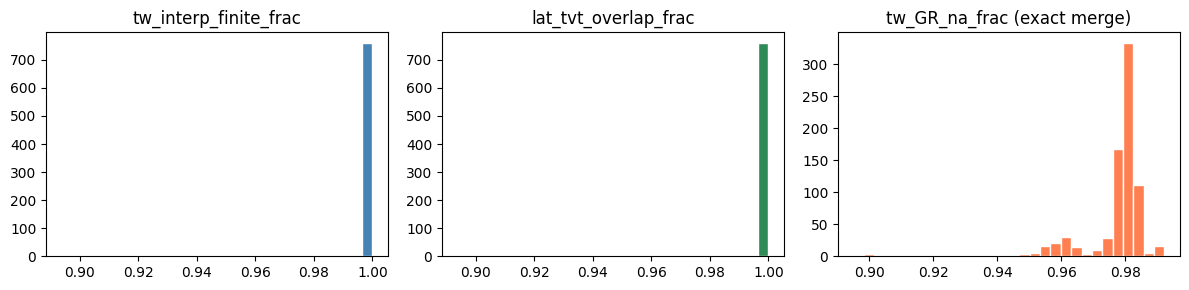

wells flagged (join-risk heuristic): 12 of 773


,well_id,lat_rows,lat_tvt_overlap_frac,tw_interp_finite_frac,tw_GR_na_frac,lat_tvt_below_tw_min,lat_tvt_above_tw_max,tw_dedup_dropped,tw_tvt_sorted_decreases
7,02e7fe5a,6888,0.935395,0.935395,0.982578,445,0,0,0
37,10b89021,7166,0.932877,0.932877,0.984231,481,0,0,0
130,2cee0cba,7335,0.982277,0.982277,0.990866,0,130,0,0
152,3417285d,7458,0.911504,0.911504,0.982837,660,0,0,0
182,3c3dbcbc,6911,0.979742,0.979742,0.979887,140,0,0,0
312,6ae68655,5948,0.929556,0.929556,0.979489,419,0,0,0
352,7993a768,7047,0.950617,0.950617,0.983539,348,0,0,0
555,bc4381e2,6885,0.912709,0.912709,0.984459,601,0,0,0
708,ecdab904,8176,0.932608,0.932608,0.982021,551,0,0,0
723,f021b650,5610,0.893761,0.893761,0.980570,596,0,0,0


In [13]:
# ---------------------------------------------------------------------------
# Iteration 5 — all training wells: join diagnostics only (read-only)
# ---------------------------------------------------------------------------
# Driver: ``wellbore_join_batch``; plots via ``plot_iter5_histograms``.

import pandas as pd
import wellbore_cv as wcv
from IPython.display import display

from wellbore_join_batch import (
    join_risk_heuristic_mask,
    plot_iter5_histograms,
    resolve_training_well_ids,
    summarize_join_for_training_wells,
)

join_data_root = wcv.default_train_root()
manifest_path = REPO_ROOT / "cv_manifests" / "kfold5_well_folds.csv"

all_train_well_ids, list_note = resolve_training_well_ids(
    manifest_path=manifest_path if manifest_path.is_file() else None,
    data_root=join_data_root,
)
print("Iteration 5 well list:", list_note, "| n =", len(all_train_well_ids))

ITER5_MAX_WELLS = None

iter5_summary_df, iter5_error_rows = summarize_join_for_training_wells(
    join_data_root,
    all_train_well_ids,
    max_wells=ITER5_MAX_WELLS,
)

print("join_data_root:", join_data_root.relative_to(REPO_ROOT))
print("wells summarized:", len(iter5_summary_df), "| load/join errors:", len(iter5_error_rows))
if iter5_error_rows:
    display(pd.DataFrame(iter5_error_rows).head(20))

if len(iter5_summary_df) == 0:
    print("iter5_summary_df is empty — check data paths and prior cells.")
else:
    numeric_columns = [
        column
        for column in iter5_summary_df.columns
        if column != "well_id" and pd.api.types.is_numeric_dtype(iter5_summary_df[column])
    ]
    display(iter5_summary_df[numeric_columns].describe().T)

    plot_iter5_histograms(iter5_summary_df)

    join_risk_mask = join_risk_heuristic_mask(iter5_summary_df)
    iter5_bad_wells_df = iter5_summary_df.loc[join_risk_mask].sort_values("well_id")
    print("wells flagged (join-risk heuristic):", len(iter5_bad_wells_df), "of", len(iter5_summary_df))
    if len(iter5_bad_wells_df):
        bad_well_display_columns = [
            "well_id",
            "lat_rows",
            "lat_tvt_overlap_frac",
            "tw_interp_finite_frac",
            "tw_GR_na_frac",
            "lat_tvt_below_tw_min",
            "lat_tvt_above_tw_max",
            "tw_dedup_dropped",
            "tw_tvt_sorted_decreases",
        ]
        bad_well_display_columns = [c for c in bad_well_display_columns if c in iter5_bad_wells_df.columns]
        display(iter5_bad_wells_df[bad_well_display_columns])


Field-wide, the join story looks consistent and healthy: clean typewell TVT grids, near-universal interp coverage, MD ordered on laterals, and exact-merge sparsity exactly where theory says it should be. The only systematic “watch list” signal in this table is wells at the low end of tw_interp_finite_frac / lat_tvt_overlap_frac (~0.89–0.95) — a small tail, not the median well.



### Join-risk QC watch list (12 wells, Iteration 5)

Heuristic: `tw_interp_finite_frac` < 0.99, `lat_tvt_overlap_frac` < 0.98, or typewell TVT grid flags (`tw_tvt_sorted_decreases`, `tw_dedup_dropped`). **Re-run Iteration 5** after manifest or training CSV changes; this table matches the notebook snapshot used to author this section.

| # | well_id |
|---|---------|
| 1 | `02e7fe5a` |
| 2 | `10b89021` |
| 3 | `2cee0cba` |
| 4 | `3417285d` |
| 5 | `3c3dbcbc` |
| 6 | `6ae68655` |
| 7 | `7993a768` |
| 8 | `bc4381e2` |
| 9 | `ecdab904` |
| 10 | `f021b650` |
| 11 | `f49fdea3` |
| 12 | `f88ddb26` |

Merged frames from `attach_typewell_by_tvt` now carry **`lat_tvt_below_tw_min`** and **`lat_tvt_above_tw_max`** (well-level counts on every foot) plus per-foot **`tw_gr_extrapolation_zone`** and **`tw_interp_missing`** (1 where `tw_GR_interp` is NaN) for model-ready join QC signal.


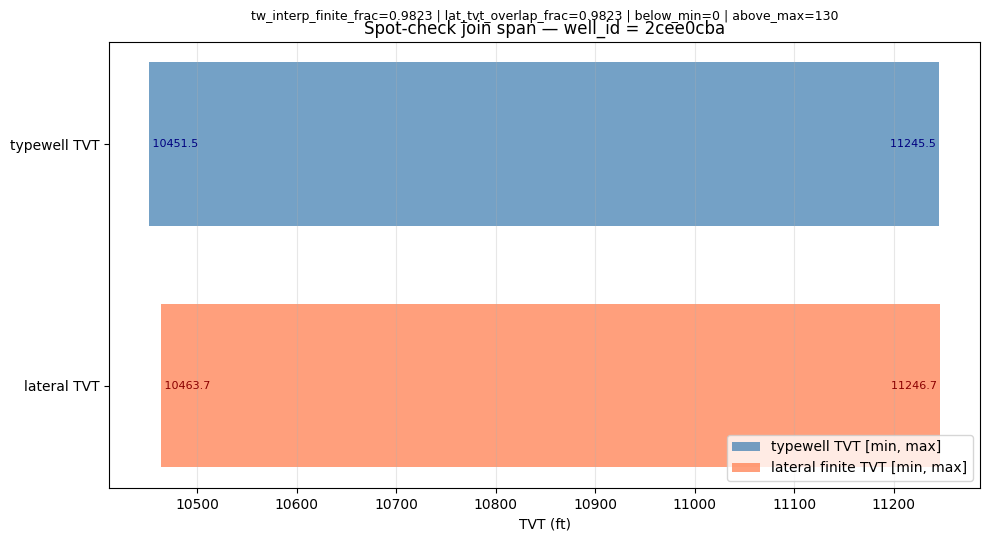

2cee0cba


In [14]:
# ---------------------------------------------------------------------------
# Spot-check: one join-risk well — lateral TVT span vs typewell TVT span
# ---------------------------------------------------------------------------
# Run after Iteration 5 (`iter5_bad_wells_df`, `join_data_root`, `iter5_summary_df`).
# Goal: see whether the lateral's finite TVT interval sits inside, overlaps, or
# extends past the typewell knot span (explains low overlap / NaN interp tails).

import matplotlib.pyplot as plt
import numpy as np
from wellbore_join import load_well_pair

if "iter5_bad_wells_df" not in dir() or "join_data_root" not in dir():
    print("Run the Iteration 5 cell first (defines iter5_bad_wells_df and join_data_root).")
elif len(iter5_bad_wells_df) == 0:
    print("iter5_bad_wells_df is empty — nothing flagged under the current heuristic.")
else:
    SPOTCHECK_WELL_ID = str(iter5_bad_wells_df.sort_values("well_id").iloc[2]["well_id"])

    lateral_sc, typewell_sc = load_well_pair(SPOTCHECK_WELL_ID, data_root=join_data_root)

    lat_tvt = lateral_sc["TVT"].to_numpy(dtype=float)
    lat_ok = np.isfinite(lat_tvt)
    lat_min, lat_max = float(np.min(lat_tvt[lat_ok])), float(np.max(lat_tvt[lat_ok]))

    tw_tvt = typewell_sc["TVT"].to_numpy(dtype=float)
    tw_ok = np.isfinite(tw_tvt)
    tw_min, tw_max = float(np.min(tw_tvt[tw_ok])), float(np.max(tw_tvt[tw_ok]))

    diag = iter5_summary_df.loc[iter5_summary_df["well_id"].astype(str) == SPOTCHECK_WELL_ID]
    subtitle = ""
    if len(diag):
        r = diag.iloc[0]
        subtitle = (
            f"tw_interp_finite_frac={r.get('tw_interp_finite_frac', float('nan')):.4f} | "
            f"lat_tvt_overlap_frac={r.get('lat_tvt_overlap_frac', float('nan')):.4f} | "
            f"below_min={int(r.get('lat_tvt_below_tw_min', 0))} | "
            f"above_max={int(r.get('lat_tvt_above_tw_max', 0))}"
        )

    fig, ax = plt.subplots(figsize=(10, 5.5))
    thickness = 0.38
    ax.broken_barh([(tw_min, tw_max - tw_min)], (0.58, thickness), facecolors="steelblue", alpha=0.75, label="typewell TVT [min, max]")
    ax.broken_barh([(lat_min, lat_max - lat_min)], (0.02, thickness), facecolors="coral", alpha=0.75, label="lateral finite TVT [min, max]")

    ax.set_yticks([0.02 + thickness / 2, 0.58 + thickness / 2])
    ax.set_yticklabels(["lateral TVT", "typewell TVT"])
    ax.set_xlabel("TVT (ft)")
    ax.set_title(f"Spot-check join span — well_id = {SPOTCHECK_WELL_ID}")
    if subtitle:
        ax.text(0.5, 1.05, subtitle, transform=ax.transAxes, ha="center", fontsize=9, clip_on=False)

    ax.text(tw_min, 0.58 + thickness / 2, f" {tw_min:.1f}", va="center", ha="left", fontsize=8, color="navy")
    ax.text(tw_max, 0.58 + thickness / 2, f"{tw_max:.1f} ", va="center", ha="right", fontsize=8, color="navy")
    ax.text(lat_min, 0.02 + thickness / 2, f" {lat_min:.1f}", va="center", ha="left", fontsize=8, color="darkred")
    ax.text(lat_max, 0.02 + thickness / 2, f"{lat_max:.1f} ", va="center", ha="right", fontsize=8, color="darkred")

    ax.legend(loc="lower right", frameon=True)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(SPOTCHECK_WELL_ID)


02e7fe5a - overhang to the left, more than double ratio, biased orange. This essentially is saying the lateral drills past where the typewell reference reaches.

10b89021 - Same story

![10b89021](data/Report%20Materials/10b89021_typewell_v_lateral_tvt_graph.png)

2cee0cba

below_min=0 — no low-side out-of-range feet.
above_max=130 — there are 130 lateral feet with finite lateral TVT above max(typewell TVT) 

![2cee0cba](data/Report%20Materials/2cee0cba_typewell_v_lateral_tvt_graph.png)

After inspecting at this level I think next we want to QC = flag and understand join health; modeling = treat missing typewell-at-lateral-TVT as a first-class missingness pattern (model NaN handling and/or explicit flags).



### <center> NA Exploration </center>

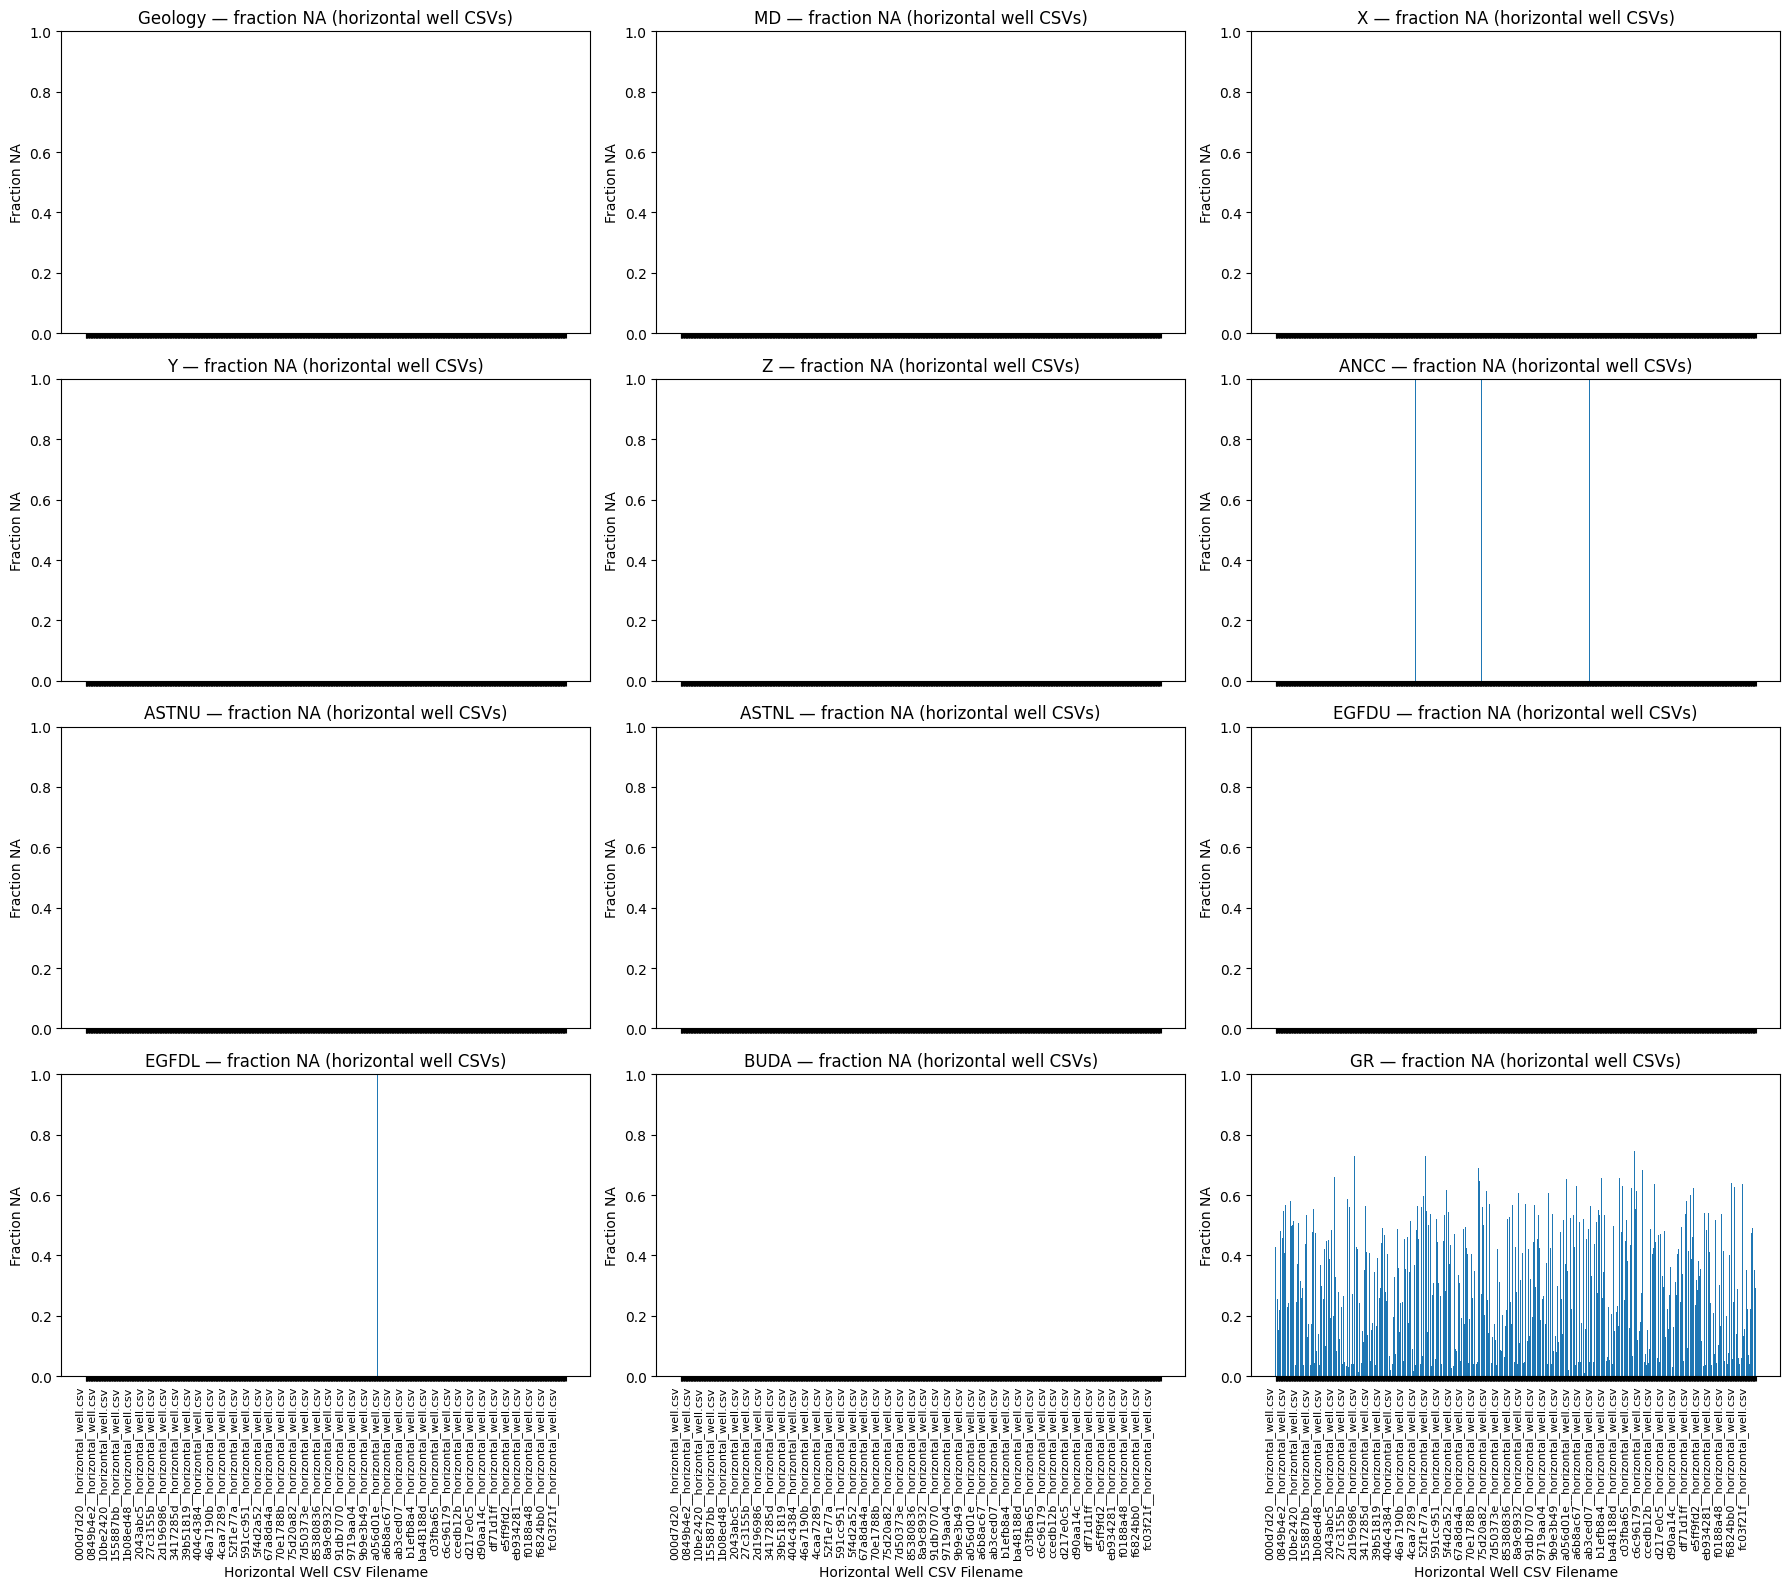

In [15]:
# We'll check the NA fraction for a set of specified columns in all available horizontal CSVs
na_columns = [
    "Geology", "MD", "X", "Y", "Z", "ANCC", "ASTNU", "ASTNL", "EGFDU", "EGFDL", "BUDA", "GR"
]
na_ratios_horizontal = {col: [] for col in na_columns}
na_ratios_horizontal["filename"] = []

# Only consider files that appear to be horizontal wells
horizontal_well_paths = [
    p for p in horizontal_paths
    if "horizontal" in p.name.lower()
]

for p in horizontal_well_paths:
    df = pd.read_csv(p)
    for col in na_columns:
        if col in df.columns:
            na_val = df[col].isna().mean()
        else:
            na_val = None
        na_ratios_horizontal[col].append(na_val)
    na_ratios_horizontal["filename"].append(p.name)

labels = na_ratios_horizontal["filename"]
ind = range(len(labels))

# Prepare NA values for each column for plotting (missing column → None → 0)
na_vals_for_plot = {
    col: [v if v is not None else 0 for v in na_ratios_horizontal[col]] for col in na_columns
}

# Create subplots, up to 4 rows x 3 cols grid (for 12 features)
fig, axes = plt.subplots(
    nrows=4, ncols=3, figsize=(18, 16), sharex=True
)
axes = axes.flatten()

for idx, col in enumerate(na_columns):
    ax = axes[idx]
    ax.bar(ind, na_vals_for_plot[col])
    ax.set_ylabel("Fraction NA")
    ax.set_title(f"{col} — fraction NA (horizontal well CSVs)")
    ax.set_ylim(0, 1)

# Only add xtick labels on the bottom plots
for i, ax in enumerate(axes):
    if i >= (len(na_columns) - 3):  # bottom row (there are 12 columns)
        ax.set_xlabel("Horizontal Well CSV Filename")
    ax.set_xticks(list(ind))
    if len(labels) > 40:
        skip = max(len(labels) // 40, 1)
        ax.set_xticklabels(
            [label if j % skip == 0 else "" for j, label in enumerate(labels)],
            rotation=90,
            fontsize=8,
            ha="right",
        )
    else:
        ax.set_xticklabels(labels, rotation=90, fontsize=8, ha="right")

# Hide any unused subplots
for j in range(len(na_columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

csv_headers = ["filename"] + na_columns
na_ratios = pd.DataFrame(na_ratios_horizontal, columns=csv_headers)
na_ratios.to_csv("na_ratios_geology.csv", index=False)

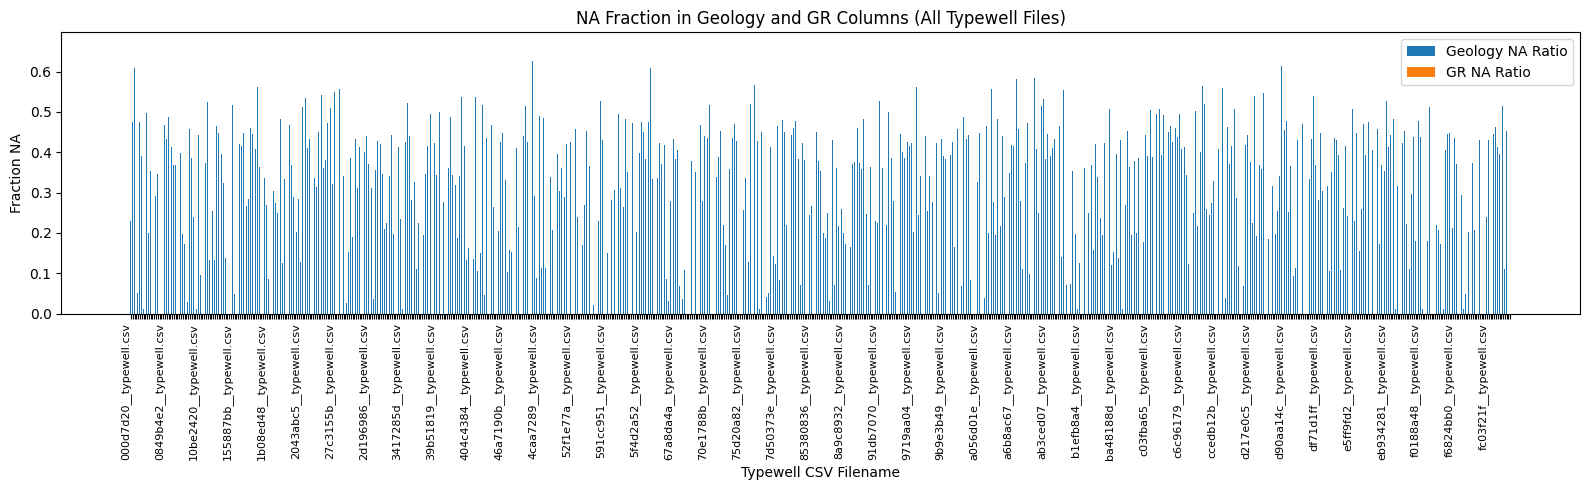

In [16]:
na_ratios_typewell = {"Geology": [], "GR": [], "filename": []}

# Only consider files that appear to be typewells
typewell_paths_filtered = [
    p for p in typewell_paths
    if "typewell" in p.name.lower()
]

for p in typewell_paths_filtered:
    df = pd.read_csv(p)
    geology_na = df["Geology"].isna().mean() if "Geology" in df.columns else None
    gr_na = df["GR"].isna().mean() if "GR" in df.columns else None
    na_ratios_typewell["Geology"].append(geology_na)
    na_ratios_typewell["GR"].append(gr_na)
    na_ratios_typewell["filename"].append(p.name)

fig, ax = plt.subplots(figsize=(16, 5))
bar_width = 0.4
labels = na_ratios_typewell["filename"]

# If there are no NA values, set to zero for plotting
geology_na_vals = [v if v is not None else 0 for v in na_ratios_typewell["Geology"]]
gr_na_vals = [v if v is not None else 0 for v in na_ratios_typewell["GR"]]

ind = range(len(labels))
ax.bar(ind, geology_na_vals, bar_width, label='Geology NA Ratio')
ax.bar([i + bar_width for i in ind], gr_na_vals, bar_width, label='GR NA Ratio')

ax.set_xticks([i + bar_width / 2 for i in ind])
# Show fewer xticklabels for readability if too many files
if len(labels) > 40:
    skip = len(labels) // 40
    ax.set_xticklabels([label if i % skip == 0 else '' for i, label in enumerate(labels)], rotation=90, fontsize=8, ha='right')
else:
    ax.set_xticklabels(labels, rotation=90, fontsize=8, ha='right')

ax.set_ylabel("Fraction NA")
ax.set_xlabel("Typewell CSV Filename")
ax.set_title("NA Fraction in Geology and GR Columns (All Typewell Files)")
ax.legend()
plt.tight_layout()
plt.show()

csv_headers  = ["filename", "Geology", "GR"]
na_ratios = pd.DataFrame(na_ratios_typewell, columns=csv_headers)
na_ratios.to_csv("na_ratios_typewell.csv", index=False)

As we can see, there are only two stray columns with a few missing values: EGFDL.And ANCC. Otherwise, the group and the geology columns are the only 2 that have significant missing values. In well log datasets, particularly from horizontal drilling, seeing missing GR data fractions jump anywhere from 10% to over 70% is highly common here. 



## <center> GR </center>

##### </enter> Description & Research </center>

GR will be interesting to deal with as the datacard describes it as:

*GR - Gamma Ray (API): Log measuring natural radioactivity of the rock.*

Internet search yields a few different explinations:

Signal Degradation: Telemetry signals from Logging While Drilling (LWD) tools weaken in long horizontal sections, causing data packets to drop.

Strategic Skipping: Operators frequently shut off logging tools once the horizontal target is reached to save costs or preserve equipment, leaving large unlogged gaps.

Sensor Failures: The extreme heat, pressure, and vibration of horizontal drilling cause temporary tool malfunctions and power dropouts.

Stitching Gaps: Missing data appears when logging runs from different drilling phases (e.g., intermediate vs. production casing) are merged and don't perfectly overlap.

Resolution Mismatches: When ETL pipelines merge high-frequency logs with lower-frequency GR logs onto a single depth index, artificial NAs are generated to fill the space.

##### <center> Plan </center>

Idea 1: Interpolation (simplest, probably best starting point)

Since GR is a depth-ordered sequence, linear or spline interpolation between known values is physically reasonable — geology doesn't jump discontinuously. Good for Short Gaps, Breaks down over Long

* Forward-fill / backward-fill as a simpler variant

* Works well for gaps caused by pipe connections (which are short)

* Breaks down for very long contiguous gaps

Need to add a binary flag column GR_was_null (1/0) alongside it so the model still knows those values were imputed. 

Idea 2: Typewell Correlation Imputation

* Domain-appropriate answer. The whole point of the typewell is to be a reference GR signature for that well. More complex.

* Align the horizontal well's TVT position to the typewell's TVT

* Pull the corresponding GR value from the typewell at that depth

This is literally what geosteers do manually. It won't be perfect but it's physically grounded. 

*Worth trying as a feature even I go interpolation.*



## <center> Geology </center>

#### <center> Description and Research </center>

Geology makes a bit more immediate sense on the NAs:

*Geology - Formation Label: Categorical label indicating the geological unit (e.g., EGFDL, BUDA).*

Geology can be missing where interpretation is uncertain, the interval is not coded, or the vertical sampling does not carry a label at that point.

Another Internet research spree yielded the following:
Why Formation Labels (Geology) Go Missing
Selective Labeling (Focusing on Pay Zones): Geologists define formation boundaries by picking "tops" and "bases" on a well log. However, they rarely label the entire well from the surface to the bottom. They usually only annotate the target reservoirs (the "pay zones") and the immediately adjacent rock layers needed for geomechanics or steering. The thousands of feet of shallow, non-commercial rock (the overburden) are often completely ignored and left blank.

Transitional Zones and Ambiguity: Stratigraphic boundaries are rarely perfectly sharp. When drilling through highly interbedded sections, fault zones, or gradual geological transitions, a geologist might intentionally leave the interval unassigned rather than guess and provide a low-confidence label.

ETL and Forward-Filling Gaps: Geological data is originally recorded as sparse, discrete depth markers (e.g., "BUDA formation starts at 8,500 ft"). When dataset creators merge these sparse markers onto a continuous, high-frequency depth index (like a sensor reading every 0.5 ft), they have to programmatically forward-fill the categorical labels. If there are gaps in the geologists' original logs, or if the pipeline doesn't handle the very bottom or very top of the well correctly, it generates NAs.

Legacy Data & Digitization: Typewells are often older, vertical "pilot" or reference wells drilled years before the surrounding horizontal wells. Much of their historical data comes from hand-annotated, digitized paper logs. If sections of the original paper log were illegible, faded, or simply never filled out by the geologist on shift, those blank spaces propagate into modern datasets as missing values.

#### <center> NA handling (typewell) </center>

Forward-fill within each typewell along **TVT** (after sorting by depth) is the practical fix: a formation name should stay in effect until the next interpreted pick replaces it. The tidy export section implements that on saved typewell CSVs; the join step still exposes raw `tw_Geology` from exact TVT matches until tidy is applied.

#### <center> Encoding strategy (from strings to numbers) </center>

**What we encode.** After `attach_typewell_by_tvt`, the lateral can carry **`tw_Geology`** — the typewell formation label aligned to each foot (exact match on TVT; often sparse until you forward-fill on the typewell). Models need **numbers**, not raw strings.

**Three common approaches (pick consciously):**

1. **Integer codes (this notebook's first pass)** — Fast for tree models. If codes follow a **defensible stratigraphic order**, splits can mimic "above / below in the column"; if codes are arbitrary, treat them as nominal IDs only (still works in boosting, but order is meaningless).

2. **One-hot or hash embeddings** — Grows wide fast when there are many labels; good when you truly have no order.

3. **Target / frequency encodings** — Powerful but **easy to leak**: never compute statistics using rows from the validation well, or from the whole train set, and then evaluate on a fold that saw those rows. The safe pattern is **re-fit encoders inside each CV training fold** on training-fold wells only.

**CV-safe reminder.** The demo code cell below builds a code map from **one well** so the notebook stays readable. When you wire this into `wellbore_cv` folds, rebuild `code_map` from **training-fold typewells only**, then encode train + val rows for that fold.

#### <center> Plan </center>

- Keep forward-fill for Geology in **Tidy** (already described later in this report).
- Add **`tw_geology_code`** on merged frames for modeling (see code cell below).
- Later experiments (document here as they land): distances to formation tops, multi-label windows, or pooled encodings that respect fold boundaries.


In [17]:
# ---------------------------------------------------------------------------
# Geology encoding — formation strings → integer codes for tree models
# ---------------------------------------------------------------------------
# Contract: ``wellbore_geology`` (fit ``build_geology_code_map`` on train-fold labels only in real CV).

import wellbore_cv as wcv
from IPython.display import display

from wellbore_geology import (
    KNOWN_FORMATION_ORDER,
    build_geology_code_map,
    encode_merged_tw_geology,
)
from wellbore_join import attach_typewell_by_tvt, load_well_pair

# ---------------------------------------------------------------------------
# Demo: single training well — end-to-end join + encoding smoke test.
# ---------------------------------------------------------------------------
geo_demo_root = wcv.default_train_root()
try:
    geo_demo_well = JOIN_PROBE_WELL_ID
except NameError:
    discovered = [
        wcv.lateral_well_stem(path)
        for path in wcv.discover_lateral_csvs(geo_demo_root)
        if wcv.lateral_well_stem(path) is not None
    ]
    geo_demo_well = sorted(set(discovered))[0] if discovered else None

if geo_demo_well is None:
    print("Geology encoding demo skipped — no lateral CSV paths discovered.")
else:
    lat_df, tw_df = load_well_pair(geo_demo_well, data_root=geo_demo_root)
    merged_demo = attach_typewell_by_tvt(lat_df, tw_df)
    if "tw_Geology" not in merged_demo.columns:
        print(
            f"Well {geo_demo_well}: merged frame has no tw_Geology "
            "(typewell missing Geology column?)."
        )
    else:
        code_map_demo = build_geology_code_map(merged_demo["tw_Geology"])
        merged_encoded = encode_merged_tw_geology(merged_demo, code_map_demo)

        print("Demo well_id:", geo_demo_well)
        print("n_distinct_labels:", len(code_map_demo))
        preview_items = list(code_map_demo.items())[:10]
        print("code_map preview:", dict(preview_items))
        print("tw_geology_code summary:")
        display(merged_encoded["tw_geology_code"].describe().to_frame().T)

        preview_cols = [c for c in ("MD", "TVT", "tw_Geology", "tw_geology_code") if c in merged_encoded.columns]
        display(merged_encoded[preview_cols].dropna(subset=["tw_Geology"]).head(12))


Demo well_id: da940160
n_distinct_labels: 4
code_map preview: {'ASTNU': 1, 'ASTNL': 2, 'EGFDU': 3, 'EGFDL': 4}
tw_geology_code summary:


,count,mean,std,min,25%,50%,75%,max
tw_geology_code,6792.0,0.087456,0.579944,0.0,0.0,0.0,0.0,4.0


,MD,TVT,tw_Geology,tw_geology_code
519,11296.0,11073.24,ASTNU,1
539,11316.0,11090.23,ASTNU,1
587,11364.0,11129.21,ASTNU,1
594,11371.0,11134.71,ASTNU,1
612,11389.0,11147.70,ASTNU,1
632,11409.0,11161.70,ASTNL,2
724,11501.0,11221.16,ASTNL,2
760,11537.0,11243.65,ASTNL,2
801,11578.0,11269.64,ASTNL,2
948,11725.0,11322.60,EGFDU,3


### <center> Other NA's </center>

ANCC and EGFDL each are the only other columns that have NA. According to Kaggle both of these features are:

ANCC, ASTNU, ASTNL, EGFDU, EGFDL, BUDA - Predicted depth of various geological formations (Training only).

So it sounds like they may be shallower or more laterally variable formations (given their names suggest different members of the same group — EGFDU being the upper, EGFDL the lower). It's plausible the three ANCC-absent wells were landed deeper and never crossed that horizon, while the one EGFDL-absent well had an unusual structural position. 

In the future: well-level clustering or geographic feature engineering are flags that could correlate with something meaningful spatially.


## <center> Tidy </center>

### <center> GR NAs </center>

To begin with our tidy step, we are going to handle the NA values in the GR column. This will take place across the horizontal Well bore data sets. Well **a4f989c2**: GR spikes **430.7** and **487.0** are set to missing before imputation so the depth-wise fill runs and **`GR_was_null`** is set on those rows.

Tidied horizontal and typewell CSVs are written in bulk to a new folder: `data/train_tidy/`. This retains the original in pristine condition. On typewells, **Geology** is forward-filled along TVT after GR imputation (last label carries downward until the next pick). PNGs were also copied into the new tree under `data/train_tidy/`. The same steps are applied to **`data/test/`** into **`data/tidytest/`** immediately after the train batch export cell (skipped if the test folder is not present on disk).

**MD grid:** the code cell at the end of this section audits horizontal `MD` spacing against a 1 ft step (summary table, per-file flags, histograms).

---


In [18]:
# ---------------------------------------------------------------------------
# Manual GR spike repair (runs before the main GR imputation).
# Listed GR values are treated as bad readings for specific wells; those
# cells are set to NaN so the imputer fills them and marks them via
# `GR_was_null` like any other missing GR.
# ---------------------------------------------------------------------------

# Well id (CSV stem before "__") -> GR readings to null out (must match file values).
GR_SPIKE_NULL_BY_WELL_STEM: dict[str, tuple[float, ...]] = {
    "a4f989c2": (430.7, 487.0),
}


def null_manual_gr_outliers(df: pd.DataFrame, csv_path: Path) -> pd.DataFrame:
    """Return a copy of df with listed GR values nulled for known-bad wells (matched by CSV stem)."""
    # Same well id prefix as in the horizontal CSV filename.
    stem = csv_path.name.split("__")[0]
    if stem not in GR_SPIKE_NULL_BY_WELL_STEM or "GR" not in df.columns:
        return df
    out = df.copy()
    gr = out["GR"].to_numpy(dtype=float, copy=False)
    # One combined mask: true where GR equals any listed spike value.
    mask = np.zeros(len(out), dtype=bool)
    for v in GR_SPIKE_NULL_BY_WELL_STEM[stem]:
        mask |= np.isclose(gr, float(v), rtol=0.0, atol=1e-6)
    out.loc[mask, "GR"] = np.nan
    return out


In [19]:
# ---------------------------------------------------------------------------
# GR imputation along depth, plus a `GR_was_null` flag column.
# GR usually changes slowly with depth; short gaps are filled with interpolation
# and small forward/back fills. Long gaps are only partly filled (limits below)
# so the routine does not invent long runs of fake log.
# ---------------------------------------------------------------------------
# Steps: sort by depth -> record original NaNs in the flag -> fill GR along depth
# -> restore the original row order.
# ---------------------------------------------------------------------------

def impute_gr_with_flag(
    df: pd.DataFrame,
    *,
    depth_col: str = "MD",
    gr_col: str = "GR",
    flag_col: str = "GR_was_null",
    strategy: str = "linear_interp_then_ffill_bfill",
    max_consecutive_na_interp: int | None = 10,
    ffill_bfill_limit: int | None = 10,
    interp_method: str = "linear",
    spline_order: int = 3,
) -> pd.DataFrame:
    """Return a copy of df with GR filled along depth; add flag_col=1 where GR was originally NA."""
    if depth_col not in df.columns or gr_col not in df.columns:
        raise KeyError(f"expected columns {depth_col!r} and {gr_col!r}")

    # Rows are ordered by depth so neighbors in the table are neighbors down-hole.
    working_df = df.sort_values(depth_col).copy()
    gr_before_fill = working_df[gr_col]

    # 1 = GR was missing before filling; helps later models treat imputed values differently.
    working_df[flag_col] = gr_before_fill.isna().astype(np.int8)

    if strategy == "ffill_bfill_only":
        # Copy last known GR downward / first known upward; limits cap how far that can reach.
        working_df[gr_col] = gr_before_fill.ffill(limit=ffill_bfill_limit).bfill(
            limit=ffill_bfill_limit
        )
        return working_df.sort_index()

    if strategy != "linear_interp_then_ffill_bfill":
        raise ValueError(f"unknown strategy: {strategy!r}")

    # Fill only short interior NaN blocks; `limit` is max consecutive NaNs bridged per gap.
    if interp_method == "linear":
        gr_after_interpolation = gr_before_fill.interpolate(
            method="linear",
            limit=max_consecutive_na_interp,
            limit_direction="both",
        )
    elif interp_method == "spline":
        gr_after_interpolation = gr_before_fill.interpolate(
            method="spline",
            order=spline_order,
            limit=max_consecutive_na_interp,
            limit_direction="both",
        )
    else:
        raise ValueError("interp_method must be 'linear' or 'spline'")

    # Catch short tails the interpolator cannot reach (top/bottom of the hole).
    gr_fully_filled = gr_after_interpolation.ffill(limit=ffill_bfill_limit).bfill(
        limit=ffill_bfill_limit
    )
    working_df[gr_col] = gr_fully_filled

    # Return rows in the same order as the input frame (undoes the depth sort).
    return working_df.sort_index()


# Demo row counts on one file: raw NaNs, after spike-nulling, after imputation.
_example_path = next(
    (p for p in horizontal_well_paths if p.name.startswith("a4f989c2")),
    horizontal_well_paths[0],
)
_raw_example = pd.read_csv(_example_path)
_example_df = null_manual_gr_outliers(_raw_example, _example_path)
_example_imputed = impute_gr_with_flag(
    _example_df,
    strategy="linear_interp_then_ffill_bfill",
    max_consecutive_na_interp=10,
    ffill_bfill_limit=10,
    interp_method="linear",
)
print("Example file:", _example_path.name)
print(
    "GR NA  raw:",
    int(_raw_example["GR"].isna().sum()),
    "| after spike null:",
    int(_example_df["GR"].isna().sum()),
    "| after impute:",
    int(_example_imputed["GR"].isna().sum()),
)
print("GR_was_null sum:", int(_example_imputed["GR_was_null"].sum()))
display(_example_imputed[["MD", "GR", "GR_was_null"]].head(12))


Example file: a4f989c2__horizontal_well.csv
GR NA  raw: 332 | after spike null: 332 | after impute: 0
GR_was_null sum: 332


,MD,GR,GR_was_null
0,10494.0,149.607422,0
1,10495.0,150.254468,0
2,10496.0,143.976377,0
3,10497.0,139.831788,0
4,10498.0,144.256181,0
5,10499.0,152.160629,0
6,10500.0,150.744124,0
7,10501.0,147.981065,0
8,10502.0,150.884026,0
9,10503.0,150.953977,0


### <center> Geology NAs </center>

Forward-fill within each typewell is probably fine since a formation label should persist until the next boundary is crossed.


In [20]:
# ---------------------------------------------------------------------------
# Typewell helper: forward-fill chosen columns along increasing depth (TVT).
# Formation labels are often stored only at picks; carrying the last label
# downward matches how strip logs are read. Rows before the first label stay NaN.
# ---------------------------------------------------------------------------

def forward_fill_along_depth(
    df: pd.DataFrame,
    *,
    depth_col: str = "TVT",
    columns: tuple[str, ...] = ("Geology",),
) -> pd.DataFrame:
    """Sort by depth, forward-fill only the listed columns that exist, restore original row order."""
    if depth_col not in df.columns:
        raise KeyError(f"missing depth column {depth_col!r}")
    # Ignore column names that are not in this file.
    cols_present = [c for c in columns if c in df.columns]
    if not cols_present:
        return df.copy()
    working_df = df.sort_values(depth_col).copy()
    # Each row inherits the latest non-null label above it on the depth axis.
    working_df[cols_present] = working_df[cols_present].ffill()
    return working_df.sort_index()


And here we are going to go ahead and batch export.We're going to do this into a new folder space so as to keep the original training data set..

In [21]:
# ---------------------------------------------------------------------------
# Batch export: read each raw train CSV, tidy it, write a mirror path under
# `data/train_tidy/` so originals in `data/train/` stay untouched.
# ---------------------------------------------------------------------------

DATA_TRAIN_TIDY = REPO_ROOT / "data" / "train_tidy"
DATA_TRAIN_TIDY.mkdir(parents=True, exist_ok=True)

# Shared knobs passed into `impute_gr_with_flag` for every file below.
_IMPUTE_KW = dict(
    strategy="linear_interp_then_ffill_bfill",
    max_consecutive_na_interp=10,
    ffill_bfill_limit=10,
    interp_method="linear",
)

def _tidy_csv_destination(src: Path, train_root: Path, tidy_root: Path) -> Path:
    # Keeps the same relative path under the new root (e.g. train/foo.csv -> train_tidy/foo.csv).
    return tidy_root / src.relative_to(train_root)


def _write_cleaned_well_csv(
    src: Path,
    train_root: Path,
    tidy_root: Path,
    depth_col: str,
    *,
    typewell_ffill_columns: tuple[str, ...] | None = None,
) -> None:
    dest = _tidy_csv_destination(src, train_root, tidy_root)
    dest.parent.mkdir(parents=True, exist_ok=True)
    df = pd.read_csv(src)
    # Optional manual spike removal for known wells (no-op if stem not listed).
    df = null_manual_gr_outliers(df, src)
    if "GR" not in df.columns:
        print(f"skip (no GR column): {src.relative_to(train_root)}")
        return
    if depth_col not in df.columns:
        print(f"skip (no {depth_col} column): {src.relative_to(train_root)}")
        return
    cleaned = impute_gr_with_flag(df, depth_col=depth_col, **_IMPUTE_KW)
    # Typewells only: fill Geology down TVT after GR has been imputed.
    if typewell_ffill_columns:
        cleaned = forward_fill_along_depth(
            cleaned,
            depth_col=depth_col,
            columns=typewell_ffill_columns,
        )
    cleaned.to_csv(dest, index=False)


# Laterals: depth column is MD along the horizontal path.
for path in horizontal_well_paths:
    _write_cleaned_well_csv(path, DATA_TRAIN, DATA_TRAIN_TIDY, depth_col="MD")

# Typewells: depth column is TVT on the vertical reference; forward-fill Geology.
for path in typewell_paths_filtered:
    _write_cleaned_well_csv(
        path,
        DATA_TRAIN,
        DATA_TRAIN_TIDY,
        depth_col="TVT",
        typewell_ffill_columns=("Geology",),
    )

print("Wrote tidied CSVs under:", DATA_TRAIN_TIDY.resolve())


Wrote tidied CSVs under: C:\Users\micha\Python Projects\Depth Charge - Wellbore Geology Competition\data\train_tidy


In [22]:
# ---------------------------------------------------------------------------
# Test split: same CSV tidy as training (GR spike rule, `impute_gr_with_flag`,
# typewell Geology ffill along TVT). Writes under `data/tidytest/` so
# `data/test/` stays untouched. Mirrors `*.png` with the same relative paths.
# ---------------------------------------------------------------------------


DATA_TEST_TIDY = REPO_ROOT / "data" / "tidytest"

if not DATA_TEST.is_dir():
    print("No data/test directory — skipped tidying test CSVs.")
else:
    DATA_TEST_TIDY.mkdir(parents=True, exist_ok=True)

    horizontal_paths_test = sorted(
        {p.resolve(): p for p in DATA_TEST.rglob("*__horizontal_well.csv")}.values()
    )
    horizontal_well_paths_test = [
        p for p in horizontal_paths_test if "horizontal" in p.name.lower()
    ]
    typewell_paths_test = sorted(
        {p.resolve(): p for p in DATA_TEST.rglob("*__typewell.csv")}.values()
    )
    typewell_paths_filtered_test = [
        p for p in typewell_paths_test if "typewell" in p.name.lower()
    ]

    for path in horizontal_well_paths_test:
        _write_cleaned_well_csv(path, DATA_TEST, DATA_TEST_TIDY, depth_col="MD")
    for path in typewell_paths_filtered_test:
        _write_cleaned_well_csv(
            path,
            DATA_TEST,
            DATA_TEST_TIDY,
            depth_col="TVT",
            typewell_ffill_columns=("Geology",),
        )

    for png in DATA_TEST.rglob("*.png"):
        dest_png = DATA_TEST_TIDY / png.relative_to(DATA_TEST)
        dest_png.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(png, dest_png)
    print(
        "Wrote tidied test CSVs and PNG mirrors under:",
        DATA_TEST_TIDY.resolve(),
    )



Wrote tidied test CSVs and PNG mirrors under: C:\Users\micha\Python Projects\Depth Charge - Wellbore Geology Competition\data\tidytest


### <center> Step Spacing </center>

So the next avenue that we want to check is Making sure that our Steps are Within one foot of each other. This is more of a data sanity check. According to the Data Card on Kaggle, the submission is scored by TVT along the lateral at *one-foot increments*, and scoring uses dTVT at those foot-by-foot points. Each horizontal well is evaluated on a **one-foot** TVT series along the lateral. If MD steps are irregular or duplicated, catching it early will avoids silent bugs.

In [23]:
# ---------------------------------------------------------------------------
# MD spacing check (horizontal wells)
# The competition score is defined on one-foot steps along the lateral; if MD
# spacing drifts from 1 ft or repeats the same depth, downstream joins and
# labels can be silently wrong. Each horizontal file becomes one summary row.
# ---------------------------------------------------------------------------
# Method: sort MD, take consecutive differences, compare each step to 1.0 ft
# within a small tolerance; duplicate depths show up as a zero step.
# ---------------------------------------------------------------------------

MD_STEP_EXPECTED = 1.0
# Numeric slack around 1.0 ft so tiny float noise from CSV export does not fail every file.
MD_STEP_ATOL = 1e-4  # bump toward 1e-2 if rounded depths cause false alarms only

md_spacing_rows = []
for path in horizontal_well_paths:
    # Load only MD for speed; spacing does not need the other columns here.
    md = pd.read_csv(path, usecols=["MD"])["MD"].to_numpy(dtype=float)
    md_sorted = np.sort(md)
    deltas = np.diff(md_sorted)
    if len(deltas) == 0:
        # Single-row (or empty-after-sort) edge case: cannot evaluate spacing.
        md_spacing_rows.append(
            {
                "relative_path": str(path.relative_to(DATA_TRAIN)),
                "n_rows": len(md_sorted),
                "median_step": np.nan,
                "max_step": np.nan,
                "max_abs_dev_from_1ft": np.nan,
                "pct_steps_close_1ft": np.nan,
                "n_duplicate_md": np.nan,
                "fails_tolerance": True,
            }
        )
        continue
    median_step = float(np.median(deltas))
    max_step = float(np.max(deltas))
    max_abs_dev = float(np.max(np.abs(deltas - MD_STEP_EXPECTED)))
    # Share of steps that match 1 ft within MD_STEP_ATOL (should be ~100% on clean data).
    pct_close = float(np.mean(np.isclose(deltas, MD_STEP_EXPECTED, atol=MD_STEP_ATOL, rtol=0)) * 100.0)
    n_dup = int(np.sum(deltas == 0))
    steps_ok = bool(np.allclose(deltas, MD_STEP_EXPECTED, atol=MD_STEP_ATOL, rtol=0))
    fails = (not steps_ok) or (n_dup > 0)
    md_spacing_rows.append(
        {
            "relative_path": str(path.relative_to(DATA_TRAIN)),
            "n_rows": len(md_sorted),
            "median_step": median_step,
            "max_step": max_step,
            "max_abs_dev_from_1ft": max_abs_dev,
            "pct_steps_close_1ft": pct_close,
            "n_duplicate_md": n_dup,
            "fails_tolerance": fails,
        }
    )

md_spacing_df = pd.DataFrame(md_spacing_rows)
n_fail = int(md_spacing_df["fails_tolerance"].sum())
print(f"Horizontal wells checked: {len(md_spacing_df)} | fail tolerance: {n_fail}")
display(md_spacing_df.describe(include="all").T)

if n_fail:
    display(md_spacing_df.loc[md_spacing_df["fails_tolerance"]].sort_values("max_abs_dev_from_1ft", ascending=False))
else:
    print("No files failed (all MD steps within atol of 1.0 and no duplicate MD).")


Horizontal wells checked: 773 | fail tolerance: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
relative_path,773,773,ffefef30__horizontal_well.csv,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_rows,773.0,NaN,NaN,NaN,6587.652005,1311.463547,2058.0,5706.0,6576.0,7388.0,12141.0
median_step,773.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
max_step,773.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
max_abs_dev_from_1ft,773.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pct_steps_close_1ft,773.0,NaN,NaN,NaN,100.0,0.0,100.0,100.0,100.0,100.0,100.0
n_duplicate_md,773.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
fails_tolerance,773,1,False,773,NaN,NaN,NaN,NaN,NaN,NaN,NaN


No files failed (all MD steps within atol of 1.0 and no duplicate MD).


### QA Check

The next thing that we want to check is for any broken XYZ pathways. This one indicate a missing row or some broken data. Don't expect to find any, but it's a good sanity check.The next thing that we want to check for is any big spikes in GR, This is the radioactivity.For this we could use a simple delta after sortation which yields of 150 variable.

In [24]:
# ---------------------------------------------------------------------------
# Light QA on horizontal CSVs (sanity pass before heavy modeling)
# Catches empty files, unreadable CSVs, GR outside a coarse API band, very large
# GR changes between consecutive MD samples, and missing X/Y/Z coordinates.
# ---------------------------------------------------------------------------
# Thresholds are intentionally broad; they flag obvious corruption, not geology.
# ---------------------------------------------------------------------------

GR_MIN, GR_MAX = 0.0, 500.0  # API-style bounds for obvious unit or corruption errors
MAX_GR_STEP = 150.0  # largest allowed |delta GR| between neighbors along ascending MD

qa_rows = []
for path in horizontal_well_paths:
    rel = str(path.relative_to(DATA_TRAIN))
    try:
        df = pd.read_csv(path)
    except Exception as exc:
        qa_rows.append(
            {
                "path": rel,
                "n_rows": np.nan,
                "gr_outside_range": np.nan,
                "max_gr_step": np.nan,
                "xyz_nan_rows": np.nan,
                "note": f"read_error: {exc}",
                "flag": True,
            }
        )
        continue

    n = len(df)
    if n == 0:
        qa_rows.append(
            {
                "path": rel,
                "n_rows": 0,
                "gr_outside_range": np.nan,
                "max_gr_step": np.nan,
                "xyz_nan_rows": np.nan,
                "note": "empty",
                "flag": True,
            }
        )
        continue

    note_parts = []

    if "GR" not in df.columns:
        note_parts.append("no GR column")

    gr_outside = np.nan
    max_gr_step = np.nan
    if "GR" in df.columns:
        valid = df["GR"].dropna()
        if len(valid):
            gr_outside = int(((valid < GR_MIN) | (valid > GR_MAX)).sum())
            if gr_outside:
                note_parts.append(f"GR outside [{GR_MIN},{GR_MAX}]: {gr_outside} rows")
        if "MD" in df.columns:
            # Rows follow measured depth; GR differences are taken along that path order.
            s = df.sort_values("MD")[["GR"]].dropna()
            if len(s) >= 2:
                max_gr_step = float(s["GR"].diff().abs().max())
                if max_gr_step > MAX_GR_STEP:
                    note_parts.append(f"GR step {max_gr_step:.1f} > {MAX_GR_STEP}")

    # Count missing trajectory coordinates (any NaN in X, Y, or Z counts one cell each).
    xyz_nan_rows = 0
    for c in ("X", "Y", "Z"):
        if c in df.columns:
            xyz_nan_rows += int(df[c].isna().sum())
    if xyz_nan_rows:
        note_parts.append(f"XYZ NaNs: {xyz_nan_rows} cell(s)")

    qa_rows.append(
        {
            "path": rel,
            "n_rows": n,
            "gr_outside_range": gr_outside,
            "max_gr_step": max_gr_step,
            "xyz_nan_rows": xyz_nan_rows,
            "note": "; ".join(note_parts),
            "flag": bool(note_parts),
        }
    )

qa_df = pd.DataFrame(qa_rows)
flagged = qa_df[qa_df["flag"]]
print(f"Checked {len(qa_df)} horizontals | flagged: {len(flagged)}")
display(flagged if len(flagged) else qa_df.head(0))


Checked 773 horizontals | flagged: 28


,path,n_rows,gr_outside_range,max_gr_step,xyz_nan_rows,note,flag
6,028d7b28__horizontal_well.csv,7761,0,208.705248,0,GR step 208.7 > 150.0,True
59,15e154a1__horizontal_well.csv,7699,0,151.832030,0,GR step 151.8 > 150.0,True
68,197f8a5a__horizontal_well.csv,8248,0,151.426417,0,GR step 151.4 > 150.0,True
167,38991fd4__horizontal_well.csv,6545,0,151.118610,0,GR step 151.1 > 150.0,True
209,46a7190b__horizontal_well.csv,5646,0,151.248627,0,GR step 151.2 > 150.0,True
221,4a335117__horizontal_well.csv,6727,0,161.509922,0,GR step 161.5 > 150.0,True
254,54a7e3c2__horizontal_well.csv,7893,0,163.359178,0,GR step 163.4 > 150.0,True
269,5a1a8fd8__horizontal_well.csv,6814,0,168.492083,0,GR step 168.5 > 150.0,True
305,684a6fc1__horizontal_well.csv,11449,0,150.348947,0,GR step 150.3 > 150.0,True
321,708caea9__horizontal_well.csv,8482,0,156.406676,0,GR step 156.4 > 150.0,True


Well, after running this, it's pretty clear that there's only a few that have a spike in AGR step.Now I did this off of a mathematical median, choosing the 150. So let's go ahead and take a check at the files themselves. I suppose if we were hitting like a different material, or I guess possibly if like the sensor came back online after a while, it could explain the spike.We'll go ahead and pull the names of the files and I'll manually check them for like NA gaps..

In [25]:
flagged_paths = qa_df[qa_df["flag"]]["path"].tolist()

for rel_path in flagged_paths:
    path = DATA_TRAIN / rel_path
    df = pd.read_csv(path).sort_values("MD").reset_index(drop=True)
    if "GR" not in df.columns:
        continue
    step_idx = df["GR"].diff().abs().idxmax()
    print(f"\n{rel_path}  (step idx={step_idx})")
    print(df.loc[max(0, step_idx-2) : step_idx+2, ["MD","GR","TVT_input"]])


028d7b28__horizontal_well.csv  (step idx=7065)
           MD          GR  TVT_input
7063  18960.0  260.299719        NaN
7064  18961.0  264.561990        NaN
7065  18962.0   55.856742        NaN
7066  18963.0   56.924592        NaN
7067  18964.0   55.856742        NaN

15e154a1__horizontal_well.csv  (step idx=701)
          MD          GR  TVT_input
699  11021.0         NaN   10824.32
700  11022.0   52.486128   10824.75
701  11023.0  204.318158   10825.18
702  11024.0         NaN   10825.60
703  11025.0  177.409077   10826.03

197f8a5a__horizontal_well.csv  (step idx=511)
          MD          GR  TVT_input
509  10568.0         NaN   10544.06
510  10569.0  169.813910   10545.00
511  10570.0  312.226850   10545.94
512  10571.0         NaN   10546.88
513  10572.0  261.751378   10547.82

38991fd4__horizontal_well.csv  (step idx=666)
          MD          GR  TVT_input
664  11101.0   59.058370   11025.03
665  11102.0  109.609792   11025.72
666  11103.0  211.084872   11026.41
667  11104.0 

Well it looks Most are pretty solid data sets. It looks like the well drills from a shale-rich interval (high GR, 200-300 API) into a clean carbonate or sandstone (low GR, 50-80 API) within 1-2 feet of measured depth. 

There is one annomolie:

a4f989c2 (383.9 step) 

16962.0  430.7   ← spike

16963.0  NaN

16964.0  487.0   ← even higher


Plan

null out the two extreme rows (430.7 and 487.0) and let the interpolation pass fill them. Add a GR_was_null flag on those rows.

K-fold validation is **by lateral well id** so MD rows from one file never straddle train and val. This notebook’s active manifest is **5-fold** (`cv_manifests/kfold5_well_folds.csv`). **Trial 1** in the Trials table logged **4-fold** results (`kfold4_well_folds.csv`) at `learning_rate=0.1`. **Trials 2–3** use the same **5-fold** manifest and `learning_rate=0.07`; see the Trials table for logged fold RMSEs and notes on the val watchlist / early-stopping wiring.


### CV — 5-fold by lateral well

Local validation holds out **entire lateral wells**. Each well’s fold is in `cv_manifests/kfold5_well_folds.csv`. Folds are a fixed **42**-seed shuffle of well ids, then round-robin assignment to **0–4** so sizes differ by at most one well.

Regenerate after refreshing training CSVs, e.g. `python wellbore_cv.py --n-splits 5 --out cv_manifests/kfold5_well_folds.csv` (defaults to `data/train_tidy/` when that folder exists). When building features, keep **horizontal + paired typewell** rows in the same fold (join on the lateral `well_id` stem).

---



In [26]:


cv_root = wcv.default_train_root()
manifest_path = wcv.REPO_ROOT / "cv_manifests" / "kfold5_well_folds.csv"

if not cv_root.is_dir():
    print("No training folder at", cv_root, "— add data/train or data/train_tidy first.")
elif not any(cv_root.rglob("*__horizontal_well.csv")):
    print("No lateral CSVs found under", cv_root)
else:
    mf = wcv.write_manifest(manifest_path, cv_root, n_splits=5, random_state=42)
    display(mf.head(10))
    print("Rows per fold:\n", mf.groupby("fold")["well_id"].count().to_string())
    train_wells, val_wells = wcv.train_val_well_ids(mf, val_fold=0)
    print(f"\nExample (val_fold=0): {len(val_wells)} val wells, {len(train_wells)} train wells.")



,well_id,fold,horizontal_relative
0,000d7d20,2,000d7d20__horizontal_well.csv
1,00bbac68,0,00bbac68__horizontal_well.csv
2,00e12e8b,0,00e12e8b__horizontal_well.csv
3,015fe0d2,1,015fe0d2__horizontal_well.csv
4,01869cd4,3,01869cd4__horizontal_well.csv
5,01982c1d,0,01982c1d__horizontal_well.csv
6,028d7b28,0,028d7b28__horizontal_well.csv
7,02e7fe5a,1,02e7fe5a__horizontal_well.csv
8,0390d174,2,0390d174__horizontal_well.csv
9,03a935ae,3,03a935ae__horizontal_well.csv


Rows per fold:
 fold
0    155
1    155
2    155
3    154
4    154

Example (val_fold=0): 155 val wells, 618 train wells.


## Model

LightGBM, something simpler like a ridge/lasso baseline

To begin.We're going to stick with a light forest model. I think it's going to be easier if we try and tackle things without the pictures first. Looking at the pictures themselves, I'm not entirely certain if they would lead to necessarily better trained models as they are graphs and pictorial representations. However, we're not gonna rule that out for future work.



---


### Simple LightGBM baseline (tidied lateral + paired typewell join)

**At a glance (joined + geology + masking):** **`train_tidy`** lateral + typewell merge; **fold-local** geology codes; **`TVT_input`** masking preserved for the sponsor channel; RMSE slice = **`VAL_METRIC_ROWS`** (`all_labeled` vs `eval_zone`); **`tw_GR_interp`** NaNs not forced to zero.

**Training table (competition-style tabular plumbing):** uses **`data/train_tidy/`** only — the mirror written by the **Tidy** batch (original `data/train` stays untouched). For each CV fold, the cell holds out **`val_fold`**, builds **`code_map = build_geology_code_map(...)`** from **non-null `tw_Geology` on training-fold wells only**, then runs **`encode_merged_tw_geology`** on **both** the train stack and the validation stack with that same map (unseen val labels → code **0**). The map is **re-fit from scratch for every fold** so validation wells never leak label vocabulary.

**Features:** `MD`, `X`, `Y`, `Z`, `GR`, optional **`GR_was_null`**, raw **`TVT_input`** (competition NaNs preserved) and **`TVT_input_ffill`** (ffill/bfill along `MD` without forcing 0), joined **`tw_GR_interp`** with **no** `fillna(0)` — NaNs stay NaN; **`tw_interp_missing`** is the explicit “no vertical GR here” flag, plus **`tw_gr_extrapolation_zone`**, **`lat_tvt_below_tw_min`**, **`lat_tvt_above_tw_max`**, and **`tw_geology_code`**. The matrix is passed straight to LightGBM (native missing-value handling).

**Target & metric:** the regressor predicts **manual `TVT`** (ft). Each fold prints **RMSE(predicted TVT, manual TVT)** on a chosen validation slice — that is the same number as **RMSE on `dTVT = manual − pred` treated as error vs 0** (the leaderboard uses the latter wording; no separate `dTVT` column is required for the score).

**Validation slice (`VAL_METRIC_ROWS` in the code cell):** default **`all_labeled`** (every val foot with non-null manual **`TVT`** — matches “RMSE on TVT for now”). Set to **`eval_zone`** to restrict RMSE to feet where **`TVT_input`** is NaN (Kaggle-style masked input) but **`TVT`** is still present — closer to **evaluation-zone** rows. Training always uses every train foot with non-null **`TVT`**.

**Rows:** non-null manual **`TVT`** for fitting. By default **all manifest folds** are scored and a **mean RMSE** is printed; set **`FOLD_INDICES_TO_SCORE = [0]`** for a faster smoke run. Test-time submission plumbing is still separate from this offline CV block.


## Tabular correlation prune + export

This block stacks all **`train_tidy`** merged frames (same roll/lag flags as the code cell below), encodes **`tw_geology_code`** using a map fit on **all pooled** training labels (fine for choosing which columns to drop; the LightGBM CV cell below still rebuilds geology **per fold** on train-fold wells only), runs **`prune_correlated_features`**, then writes **merged** CSVs under **`data/tabular_pruned/train/`** and **`data/tabular_pruned/test/`** when **`data/tidytest/`** exists. Toggle **`RUN_TABULAR_PRUNE_EXPORT`** to skip a slow full-tree pass.

In [ ]:
# --- Prune + export merged tabulars (does not modify train_tidy / tidytest) ----
from wellbore_geology import build_geology_code_map, encode_merged_tw_geology

import wellbore_feature_pruning as wbprune

RUN_TABULAR_PRUNE_EXPORT = True
PRUNE_CORR_THRESHOLD = 0.95
USE_V3_ROLL_FOR_PRUNE = True
USE_V3_LAG_FOR_PRUNE = True

TRAIN_TIDY_ROOT = REPO_ROOT / "data" / "train_tidy"
TEST_TIDY_ROOT = REPO_ROOT / "data" / "tidytest"
PRUNED_TRAIN_DIR = REPO_ROOT / "data" / "tabular_pruned" / "train"
PRUNED_TEST_DIR = REPO_ROOT / "data" / "tabular_pruned" / "test"
PRUNE_META_JSON = REPO_ROOT / "data" / "tabular_pruned" / "prune_metadata.json"

if not RUN_TABULAR_PRUNE_EXPORT:
    print("Skipping tabular prune export (RUN_TABULAR_PRUNE_EXPORT=False).")
elif not TRAIN_TIDY_ROOT.is_dir():
    print("Skip prune export: missing", TRAIN_TIDY_ROOT)
else:
    stack = wbprune.stack_merged_frames_for_pruning(
        TRAIN_TIDY_ROOT,
        use_roll=USE_V3_ROLL_FOR_PRUNE,
        use_lag=USE_V3_LAG_FOR_PRUNE,
    )
    if stack.empty or "TVT" not in stack.columns:
        print("Skip prune export: empty stack or no TVT column.")
    else:
        if "tw_Geology" in stack.columns:
            cmap = build_geology_code_map(stack["tw_Geology"])
            stack = encode_merged_tw_geology(stack, cmap)
        else:
            stack["tw_geology_code"] = np.int32(0)

        _pruned_stack, prune_res = wbprune.prune_correlated_features(
            stack,
            "TVT",
            threshold=PRUNE_CORR_THRESHOLD,
        )
        print(
            f"Prune: dropped {len(prune_res.dropped_columns)} / "
            f"{prune_res.n_feature_candidates_initial} feature candidates; "
            f"{prune_res.n_feature_candidates_final} survive."
        )

        wbprune.save_prune_metadata(
            PRUNE_META_JSON,
            result=prune_res,
            threshold=PRUNE_CORR_THRESHOLD,
            use_roll=USE_V3_ROLL_FOR_PRUNE,
            use_lag=USE_V3_LAG_FOR_PRUNE,
            data_root=str(TRAIN_TIDY_ROOT.resolve()),
        )
        print("Wrote metadata:", PRUNE_META_JSON.resolve())

        n_tr = wbprune.export_pruned_merged_tabular(
            TRAIN_TIDY_ROOT,
            PRUNED_TRAIN_DIR,
            prune_res.kept_columns,
            use_roll=USE_V3_ROLL_FOR_PRUNE,
            use_lag=USE_V3_LAG_FOR_PRUNE,
        )
        print("Wrote", n_tr, "pruned merged train CSVs under", PRUNED_TRAIN_DIR.resolve())

        if TEST_TIDY_ROOT.is_dir():
            n_te = wbprune.export_pruned_merged_tabular(
                TEST_TIDY_ROOT,
                PRUNED_TEST_DIR,
                prune_res.kept_columns,
                use_roll=USE_V3_ROLL_FOR_PRUNE,
                use_lag=USE_V3_LAG_FOR_PRUNE,
            )
            print("Wrote", n_te, "pruned merged test CSVs under", PRUNED_TEST_DIR.resolve())
        else:
            print("No tidy test tree at", TEST_TIDY_ROOT, "— skipped test export.")

In [ ]:
# ---------------------------------------------------------------------------
# LightGBM baseline — training table = train_tidy + join + fold-safe geology
# ---------------------------------------------------------------------------
# Requires (run earlier notebook cells first):
#   - Imports, REPO_ROOT; **join:** ``from wellbore_join import attach_typewell_by_tvt`` (also re-exported in Iteration 4 cell)
#   - Geology: ``wellbore_geology`` (imported below with join)
#   - CV manifest: ``cv_manifests/kfold5_well_folds.csv``
#
# Fold-safe geology: **for each** held-out fold, ``code_map`` is fit on **training-fold
# wells only** (concatenated ``tw_Geology``), then **both** train and val stacks are
# encoded with that map so validation labels never influence the mapping.
#
# Policy: **only** ``data/train_tidy/`` for this baseline.
#
# --- Target & metric (competition alignment) ---------------------------------
# **Target column:** manual ``TVT`` (ft) — what the sponsor labels on each lateral foot.
# **Metric:** RMSE between predicted TVT and manual TVT. That is the same number as
# RMSE on ``dTVT = manual_TVT - pred`` treated as error vs 0 (``sqrt(mean(dTVT**2))``).
# We do not build a separate ``dTVT`` column here; reporting RMSE on TVT is enough.
#
# ``VAL_METRIC_ROWS`` controls **which validation feet** enter RMSE (training always uses
# every train foot with non-null ``TVT``). See ``validation_frame_for_rmse`` below.
#
# Trials 2–3 (Trials table): 5-fold manifest + learning_rate=0.07; val watchlist + early stopping via fit(callbacks=...).

# Score every manifest fold by default; set to ``[0]`` or ``range(1)`` for a quicker run.
FOLD_INDICES_TO_SCORE: list[int] | None = None  # None → all folds present in the manifest

VAL_METRIC_ROWS: str = "all_labeled"  # "all_labeled" | "eval_zone"

# Paths — mirror ``DATA_TRAIN_TIDY`` / manifest setup from earlier cells so this cell
# does not depend on another cell having left ``COMPETITION_TRAIN_TIDY`` in globals.
manifest_path = REPO_ROOT / "cv_manifests" / "kfold5_well_folds.csv"
# After the prune-export cell, set True to read merged CSVs from ``data/tabular_pruned/train/``.
USE_TABULAR_PRUNED_TRAIN = False
COMPETITION_TRAIN_TIDY = (
    REPO_ROOT / "data" / "tabular_pruned" / "train"
    if USE_TABULAR_PRUNED_TRAIN
    else REPO_ROOT / "data" / "train_tidy"
)

from wellbore_join import attach_typewell_by_tvt
from wellbore_geology import build_geology_code_map, encode_merged_tw_geology

if not COMPETITION_TRAIN_TIDY.is_dir():
    print(
        "Skip: no folder",
        COMPETITION_TRAIN_TIDY,
        "— run the train tidy batch export first.",
    )
elif not any(COMPETITION_TRAIN_TIDY.rglob("*__horizontal_well.csv")):
    print("Skip: no tidied lateral CSVs under", COMPETITION_TRAIN_TIDY)
elif not manifest_path.is_file():
    print("Skip: manifest not found — run the CV cell above first:", manifest_path)
else:
    mf = wcv.load_manifest(manifest_path)

    import wellbore_features as wbfeat

    # Milestone 1 (V3): per-well rolling mean / median / d(col)/dMD over 5/10/20 ft (rows after MD sort).
    USE_V3_ROLL_FEATURES = True
    # Milestone 2 (V3): per-well lag / diff / ratio vs k ft back along MD (row shifts after MD sort; leading k ft are NaN).
    USE_V3_LAG_FEATURES = True

    def _read_numeric_horizon(df: pd.DataFrame) -> pd.DataFrame:
        """Coerce common lateral columns to float (in-place safe on a copy)."""
        out = df.copy()
        for col in ("MD", "X", "Y", "Z", "GR", "TVT_input", "TVT"):
            if col in out.columns:
                out[col] = pd.to_numeric(out[col], errors="coerce")
        if "GR_was_null" in out.columns:
            out["GR_was_null"] = (
                pd.to_numeric(out["GR_was_null"], errors="coerce").fillna(0).astype(np.int8)
            )
        return out

    def _read_numeric_typewell(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        for col in ("TVT", "GR", "MD"):
            if col in out.columns:
                out[col] = pd.to_numeric(out[col], errors="coerce")
        return out

    def load_merged_from_train_tidy(well_id: str, lateral_rel: str) -> pd.DataFrame | None:
        """Load tidied pair, attach typewell, add ``well_id`` + ``TVT_input_ffill``."""
        lateral_path = COMPETITION_TRAIN_TIDY / lateral_rel
        if not lateral_path.is_file():
            print("missing lateral:", lateral_path.relative_to(REPO_ROOT))
            return None
        typewell_path = lateral_path.with_name(
            lateral_path.name.replace("__horizontal_well.csv", "__typewell.csv")
        )
        if not typewell_path.is_file():
            print("missing typewell:", typewell_path.relative_to(REPO_ROOT))
            return None

        lateral_df = _read_numeric_horizon(pd.read_csv(lateral_path))
        typewell_df = _read_numeric_typewell(pd.read_csv(typewell_path))
        merged = attach_typewell_by_tvt(lateral_df, typewell_df)
        merged["well_id"] = well_id

        merged = merged.sort_values("MD", kind="mergesort").reset_index(drop=True)
        if "TVT_input" in merged.columns:
            merged["TVT_input_ffill"] = merged["TVT_input"].ffill().bfill()
        else:
            merged["TVT_input_ffill"] = np.nan

        if USE_V3_ROLL_FEATURES:
            merged = wbfeat.add_alonghole_roll_features(merged)
        if USE_V3_LAG_FEATURES:
            merged = wbfeat.add_alonghole_lag_features(merged)

        return merged

    def collect_train_fold_geology_labels(train_well_ids: set[str]) -> pd.Series:
        """
        Concatenate every ``tw_Geology`` value seen on **training-fold** lateral feet
        (pre-encode). Validation wells must **not** contribute here — that would leak
        rare formation names into the vocabulary.
        """
        parts: list[pd.Series] = []
        sub = mf.loc[mf["well_id"].isin(train_well_ids), ["well_id", "horizontal_relative"]]
        for _, row in sub.iterrows():
            m = load_merged_from_train_tidy(str(row["well_id"]), str(row["horizontal_relative"]))
            if m is None or "tw_Geology" not in m.columns:
                continue
            parts.append(m["tw_Geology"])
        return pd.concat(parts, ignore_index=True) if parts else pd.Series(dtype="object")

    def stack_merged_with_geology_map(
        well_ids: set[str],
        geology_code_map: dict[str, int],
    ) -> pd.DataFrame:
        """Merge + encode with the **same** ``geology_code_map`` for every well in the set."""
        chunks: list[pd.DataFrame] = []
        sub = mf.loc[mf["well_id"].isin(well_ids), ["well_id", "horizontal_relative"]]
        for _, row in sub.iterrows():
            m = load_merged_from_train_tidy(str(row["well_id"]), str(row["horizontal_relative"]))
            if m is None:
                continue
            if "tw_Geology" in m.columns:
                m = encode_merged_tw_geology(m, geology_code_map)
            else:
                m["tw_geology_code"] = np.int32(0)
            chunks.append(m)
        return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()

    def validation_frame_for_rmse(val_df: pd.DataFrame) -> tuple[pd.DataFrame, str]:
        """
        Pick validation rows used for RMSE(pred TVT, manual TVT).

        ``eval_zone`` ≈ leaderboard slice: ``TVT_input`` is NaN (channel masked) but
        manual ``TVT`` still exists in training exports.
        """
        if VAL_METRIC_ROWS == "all_labeled":
            return val_df, "all labeled val rows (manual TVT present)"
        if VAL_METRIC_ROWS != "eval_zone":
            raise ValueError(f"VAL_METRIC_ROWS must be 'all_labeled' or 'eval_zone', got {VAL_METRIC_ROWS!r}")
        if "TVT_input" not in val_df.columns:
            return val_df, "eval_zone requested but no TVT_input column — using all labeled val rows"
        mask = val_df["TVT_input"].isna() & val_df["TVT"].notna()
        zone = val_df.loc[mask]
        if len(zone) == 0:
            return val_df, "eval_zone empty — falling back to all labeled val rows"
        return zone, "eval-zone proxy (TVT_input is NaN, manual TVT present)"

    candidate_feats = [
        "MD",
        "X",
        "Y",
        "Z",
        "GR",
        "GR_was_null",
        "TVT_input",
        "TVT_input_ffill",
        "tw_GR_interp",
        "tw_interp_missing",
        "tw_gr_extrapolation_zone",
        "lat_tvt_below_tw_min",
        "lat_tvt_above_tw_max",
        "tw_geology_code",
    ]
    if USE_V3_ROLL_FEATURES:
        candidate_feats = candidate_feats + wbfeat.roll_feature_column_names()
    if USE_V3_LAG_FEATURES:
        candidate_feats = candidate_feats + wbfeat.lag_feature_column_names()

    fold_ids = sorted(mf["fold"].astype(int).unique().tolist())
    folds_to_run = (
        fold_ids if FOLD_INDICES_TO_SCORE is None else [f for f in FOLD_INDICES_TO_SCORE if f in fold_ids]
    )

    per_fold_rmse: list[tuple[int, float, int]] = []

    for val_fold in folds_to_run:
        train_wells, val_wells = wcv.train_val_well_ids(mf, val_fold=val_fold)

        # --- Fold-local vocabulary from **training** wells only -----------------
        train_geology_series = collect_train_fold_geology_labels(train_wells)
        geology_code_map = build_geology_code_map(train_geology_series)

        # --- Encode train and val with that **same** map ------------------------
        train_df = stack_merged_with_geology_map(train_wells, geology_code_map)
        val_df = stack_merged_with_geology_map(val_wells, geology_code_map)

        train_df = train_df.loc[train_df["TVT"].notna()].copy()
        val_df = val_df.loc[val_df["TVT"].notna()].copy()

        feat_cols = [c for c in candidate_feats if c in train_df.columns and c in val_df.columns]

        if not feat_cols:
            print(f"Fold {val_fold}: skip — no overlapping feature columns.")
            continue

        X_train = train_df[feat_cols].copy()
        y_train = train_df["TVT"].to_numpy(dtype=float)
        X_val = val_df[feat_cols].copy()
        y_val = val_df["TVT"].to_numpy(dtype=float)

        print(
            f"--- Fold {val_fold} | train rows={len(train_df)} | val rows={len(val_df)} | "
            f"geology codes (train-fit)={len(geology_code_map)} ---"
        )

        callbacks = [
            lgb.early_stopping(stopping_rounds=50, first_metric_only=False, verbose=True)
        ]

        # Pass callbacks into fit(), not the estimator — older LightGBM builds
        # treat constructor ``callbacks`` as unknown booster kwargs (Trial 3 warnings).
        model = lgb.LGBMRegressor(
            n_estimators=3200,
            learning_rate=0.015,
            num_leaves=31,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbose=1,
        )
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            eval_metric="rmse",
            callbacks=callbacks,
        )


        val_metric_df, metric_note = validation_frame_for_rmse(val_df)
        X_met = val_metric_df[feat_cols].copy()
        y_met = val_metric_df["TVT"].to_numpy(dtype=float)
        pred = model.predict(X_met)
        rmse = float(np.sqrt(np.mean((pred - y_met) ** 2)))
        per_fold_rmse.append((val_fold, rmse, len(geology_code_map)))
        print(
            f"Fold {val_fold} RMSE on manual TVT (ft): {rmse:.4f}  ;  {metric_note}  ;  n={len(val_metric_df)}"
        )

        # Full importances only for the first scored fold to keep output readable.
        if val_fold == folds_to_run[0]:
            print("Feature importances (gain), first scored fold:")
            for name, imp in sorted(
                zip(feat_cols, model.feature_importances_), key=lambda x: -x[1]
            ):
                print(f"  {name}: {imp}")

    if per_fold_rmse:
        mean_rmse = float(np.mean([r for _, r, _ in per_fold_rmse]))
        print(
            "\nCV summary (fold-safe geology, RMSE on manual TVT):",
            " ; ".join(f"fold{f}:{r:.3f}" for f, r, _ in per_fold_rmse),
            f"; mean RMSE={mean_rmse:.4f}",
        )


--- Fold 0 | train rows=4079931 | val rows=1012324 | geology codes (train-fit)=31 ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.123411 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18877
[LightGBM] [Info] Number of data points in the train set: 4079931, number of used features: 86
[LightGBM] [Info] Start training from score 11500.022342
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[3200]	valid_0's rmse: 15.1845	valid_0's l2: 230.569
Fold 0 RMSE on manual TVT (ft): 15.1845  ;  all labeled val rows (manual TVT present)  ;  n=1012324
Feature importances (gain), first scored fold:
  TVT_input_ffill: 21754
  X: 12346
  Y: 11429
  TVT_input: 9427
  Z: 3669
  Z_lag10ft: 3472
  Z_roll20ft_mean: 2594
  MD: 2533
  Z_roll20ft_median: 2528
  Z_lag3ft: 2229
  MD_lag3ft: 2134
  Z_roll20ft_grad: 2069
  MD_ratio_lag3ft: 1455
  MD_ratio_lag10ft:

| Trial | Parameters | Setup & Data | CV / Validation Strategy | Results (RMSE) | Notes / Comments |
|-------|------------|--------------|-------------------------|----------------|------------------|
| 1 | `n_estimators=3000`, `learning_rate=0.015`, `num_leaves=31`, `min_child_samples=20`, `subsample=0.8`, `colsample_bytree=0.8`, `random_state=42`, `verbose=1` <br> `early_stopping_rounds=50` via `fit(callbacks=...)` | V3 notebook LightGBM cell (fresh run). <br> `cv_manifests/kfold5_well_folds.csv`; fold-safe geology (`wellbore_geology`); join `train_tidy` (`wellbore_join`) | `VAL_METRIC_ROWS=all_labeled`; `USE_V3_ROLL_FEATURES` per cell flag. | CV summary (fold-safe geology, RMSE on manual TVT): <br> fold0: 14.728 <br> fold1: 18.458 <br> fold2: 16.647 <br> fold3: 19.443 <br> fold4: 15.654 <br> **mean RMSE = 16.9860** | Mean CV RMSE improved vs historical Trial 2 row in this CSV; see notebook cell for feature importances. |
| 2 | `n_estimators=2800`, `learning_rate=0.015`, `num_leaves=31`, `subsample=0.8`, `colsample_bytree=0.8`, `random_state=42`, `verbose=-1` |  **Dropped estimators to 2800** V3 notebook LightGBM cell (fresh run). <br> `cv_manifests/kfold5_well_folds.csv`; fold-safe geology (`wellbore_geology`); join `train_tidy` (`wellbore_join`) | `VAL_METRIC_ROWS=all_labeled`; `USE_V3_ROLL_FEATURES` per cell flag. | **CV summary** (fold-safe geology, RMSE on manual TVT): fold0:14.761 ; fold1:18.458 ; fold2:16.647 ; fold3:19.521 ; fold4:15.654 ; **mean RMSE=17.0082** | Decreasing estimators slightly decreased the accuracy in two well folds. For fun we'll try a little higher just to test.  |
| 3 | `n_estimators=3200`, `learning_rate=0.015`, `num_leaves=31`, `subsample=0.8`, `colsample_bytree=0.8`, `random_state=42`, `verbose=-1` |  **Upped estimators to 3200** V3 notebook LightGBM cell (fresh run). <br> `cv_manifests/kfold5_well_folds.csv`; fold-safe geology (`wellbore_geology`); join `train_tidy` (`wellbore_join`) | `VAL_METRIC_ROWS=all_labeled`; `USE_V3_ROLL_FEATURES` per cell flag. | **CV summary (fold-safe geology, RMSE on manual TVT):** fold0:14.701 ; fold1:18.458 ; fold2:16.647 ; fold3:19.402 ; fold4:15.654 ; **mean RMSE=16.9725** | Decreasing estimators slightly decreased the accuracy in two well folds. For fun we'll try a little higher just to test.  |

## Conclusion

As of **Version 3**, this report **builds on Version 2**: it ties together **tidied data**, **lateral/typewell joins**, **fold-safe geology encoding**, and explicit **input masking / RMSE slice** choices. **Version 3** extends that stack toward **sequence-aware tabular features** (rolling statistics, lags, boundary distance) and **Kaggle-ready test inference** aligned with **`sample_submission.csv`**.

---



## References and acknowledgements



- Competition: https://www.kaggle.com/competitions/rogii-wellbore-geology-prediction

- [Geosteering & LWD overview — ScienceDirect Topics](https://www.sciencedirect.com/topics/engineering/logging-while-drilling)

- [SPE paper: Geosteering using Gamma Ray (OnePetro)](https://onepetro.org/SPEATCE/proceedings/25ATCE/25ATCE/D021S015R008/792004)
